# DQPRM

## Exercices de mise en pratique en Python

#### Albertine Dubois - albertine.dubois@cea.fr, Ludovic Ferrer - Ludovic.Ferrer@ico.unicancer.fr & Marion Savanier - marion.savanier@cea.fr

Version 2026


---

In [8]:
#%pip install pandas matplotlib

## Exercice 1 - Calcul automatique de l'IMC d'un individu

Ecrire une fonction qui calcule l'indice de masse corporelle (IMC) d'un(e) patient(e) donné(e)

* La fonction nécessitera 2 paramètres en entrée, le poids (en $kg$) et la taille (en $m$), et renverra la valeur de l'IMC en sortie
* Suivant la valeur d'IMC, la fonction devra également fournir une interprétation du résultat (maigreur, IMC normal, surpoids, obésité, obésité massive)
* Tester la fonction avec différents couples de valeurs poids/taille

**Rappel :**

<img width=400 src='./data/imc.gif'>

---

In [2]:
def indice_de_masse_corporelle(weight, height): # creation de la focntion pour calculer l'IMC
    imc = weight / (height ** 2)  # Indiquer la formule pour calculer l'IMC.
    print("IMC = {:0.1f}".format(imc))
    if imc <= 18.5:
        print("Valeur d'IMC indiquant une maigreur")
    elif 18.5 < imc <= 24.9:
        print("Valeur d'IMC normal")
    elif 24.9 < imc <= 29.9:
        print("Valeur d'IMC indiquant un surpoids")
    elif 29.9 < imc <= 39.9:
        print("Valeur d'IMC indiquant un obésité")
    else :
        print("Valeur d'IMC indiquant une obésité massive")
    return imc

imc = indice_de_masse_corporelle(float(input("Entrez votre poids en kg : ")), float(input("Entrez votre taille en m : ")))

Entrez votre poids en kg :  72
Entrez votre taille en m :  1.72


IMC = 24.3
Valeur d'IMC normal


## Exercice 2 - Suivi glycémie
-----------

**Question 1.** Lire avec la bibliothèque Pandas le fichier `glycemie.csv` contenu dans le dossier `data` (attention au séparateur décimal : . ou , ?)

**Question 2.** Tracer sur un même graphique, dont vous fixerez les dimensions, les courbes de la variation au cours du temps de la glycémie de ce patient pour chacun des points de mesure renseigné par colonne

**Question 3.** Indiquer le nom des axes et la légende

In [7]:
import pandas as pd

df = pd.read_csv('/Users/samy/Downloads/TP_Python/TP_Lina/data/glycemie.csv')
df

FileNotFoundError: [Errno 2] No such file or directory: '/Users/samy/Downloads/TP_Python/TP_Lina/data/glycemie.csv'

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

for time in df.columns[1:]: # Identifier les colonnes de points de mesure par un slicing
    print(time)
    if not 'AUCUN' in time:
        plt.plot(df['Date'], df[time], label = time)
        plt.xticks(df['Date'], rotation = 45)
        plt.ylabel('Glycémie (g/l)',size=14)
        plt.xlabel('Date',size=14)
        plt.legend()

NameError: name 'df' is not defined

<Figure size 1500x500 with 0 Axes>

## Exercice 3 - Dosimétrie
-----------

### Contexte
**Radioembolisation** dans le traitement d'un cancer hépatique à l'aide de **microsphères de verre** marquées à l'$^{90}Y$.

Planification de l'activité à administrer à l'aide d'une acquisition tomographique réalisée au $^{99m}Tc$-MAA

- Déterminer l'activité d'$^{90}Y$ pour délivrer une dose absorbée limite de 120 Gy au lobe hépatique contenant la tumeur
- Déterminer la dose absorbée à la tumeur

Pour illustrer le propos de l'impact de la dosimétrie prévisionnelle dans le traitement des hépatocarcinome, voir [ici](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4731431/#!po=84.5455).

### Modéle de partionnement

[Ho et al.](https://www.ncbi.nlm.nih.gov/pubmed/8753684) ont défini un modèle de calcul basée sur la connaissance de **la répartition de l'activité** dans le foie après la perfusion des microsphères radioactives. Le calcul de la dose absorbée aux  volumes d'intérêt est estimée par la méthologie du *MIRD*.

L'activité perfusée dans le foie se répartie dans lui-même et les poumons s'il existe un *shunt* entre ce premier et ces derniers.

- L'activité dans les poumons est estimée par $A_L = A_{inj.} \times \frac{L}{100}$
    - L pourcentage de shunt pulmonaire
- L'activité dans le foie comprenant la partie saine ($A_N$) et tumorale ($A_T$) est estimée par $A_N+A_T = A_{inj.} (1-\frac{L}{100})$
- Le rapport tumeur/foie sain $r=\frac{\frac{A_T}{m_T}}{\frac{A_N}{m_N}}$ peut être estimé à partir des pseudo-concentrations d'activité mesurées par la segmentation dans la tumeur et le foie sain. A l'aide de l'équation précédente, on peut ensuite exprimer les activités dans le foie sain ($A_N$) et dans la tumeur ($A_T$) en fonction de ce rapport et de $A_{inj.}$.

### Rappels

#### Equation du MIRD

$$ \bar{D}_{k \leftarrow h} = \sum_{h} \tilde{A}_{h} \times S_{k \leftarrow h} $$

où $\tilde{A}_{h}$ est l'activité cumulée dans la source i.e: le **nombre total de désintégration dans la source h** et $S_{k \leftarrow h}$ **le facteur S** liant la source h à la cible k.

#### Equation simplifiée
Dans le cas la cas d'une **radioembolisation**,
- toute l'activité injectée est piègée dans le foie (si pas de *shunt pulmonaire*)
- seule la décroissance physique du radionucléide intervient (pas d'élimination biologique du traceur).

Cela simplifie le calcul

$$\bar{D}_{foie} = A(0)_{foie} \times \frac{T_{phys.}}{ln\,2} \times S_{foie \leftarrow foie}$$

Dans le cas où on utilise un radionucléide qui émet **uniquement des émissions $\beta^-$**, la dernière équation est équivalente à :

$$ \bar{D}_{foie} = A(0)_{foie} \times \frac{T_{phys.} \times \Delta}{ln\,2\times m_{foie}}$$

où $\Delta$ représente **l'énergie totale émise par transition** et $m_{foie}$ la masse du foie.

En réorganisant les équations, on obtient l'activité à injecter pour une dose absorbée déterminée

$$ A(0)_{foie} = \frac{\bar{D}_{foie} \times m_{foie} \times ln\,2}{T_{phys.}\times \Delta}$$

Dans le cadre d'un traitement par radioembolisation avec des µ-sphères de verre, on souhaite délivrer une dose absorbée de 120 Gy dans **l'ensemble du foie perfusé**.

**Question 1.** Lire avec Pandas le fichier `Table.csv` contenu dans le dossier `data` qui contient les valeurs des différents volumes d'intérêt ainsi que les activités dans ces volumes (attention au format du séparateur de colonnes). La première colonne sera utilisée comme index des lignes.

**Question 2.** Ajouter une colonne au tableau avec les masses des différents volumes d'intérêt (on prendra comme valeur de masse volumique $\rho=1.03\ g/cm^3$)

**Question 3.** Déterminer l'activité à injecter dans le lobe droit pour atteindre cette dose absorbée limite en utilisant l'équation simplifiée du MIRD

**Question 4.** Déterminer la dose absorbée à la tumeur pour cette activité injectée

NB. Il n'y a pas eu de shunt pulmonaire identifié durant cette procédure

Données :
* Période de l'yttrium 90 : 64,05 $heures$
* Energie totale émise par transition : 0.9336 $\frac{MeV}{Bq.s}$
* On considère que les tissus hépatiques et la tumeur ont une masse volumique égale à 1.03 $\frac{g}{cm^3}$

In [179]:
import pandas as pd

df = pd.read_csv('/Users/samy/Downloads/TP_Python/TP_Lina/data/Table.csv', sep='\t')
df

,Segment,Number of voxels [voxels],Volume [mm3],Volume [cm3],Minimum,Maximum,Mean,Median,Standard Deviation
0,foie_total,13024,1124660.00,1124.66000,1,8735,1153.240,1146,941.664
1,tum_dome_CT,125,10794.20,10.79420,1651,8735,3923.500,3629,1466.790
2,lobe_droit,9375,809562.00,809.56200,31,8735,1526.330,1384,847.588
3,tum_dome_SPECT,114,9844.27,9.84427,4163,8735,5341.220,5034,980.795
4,lobe_gauche,3653,315448.00,315.44800,1,1955,195.493,117,207.995


In [180]:
rho_g_per_cm3 = 1.03
df['Masse [g]'] = df['Volume [cm3]'] * rho_g_per_cm3
df

,Segment,Number of voxels [voxels],Volume [mm3],Volume [cm3],Minimum,Maximum,Mean,Median,Standard Deviation,Masse [g]
0,foie_total,13024,1124660.00,1124.66000,1,8735,1153.240,1146,941.664,1158.399800
1,tum_dome_CT,125,10794.20,10.79420,1651,8735,3923.500,3629,1466.790,11.118026
2,lobe_droit,9375,809562.00,809.56200,31,8735,1526.330,1384,847.588,833.848860
3,tum_dome_SPECT,114,9844.27,9.84427,4163,8735,5341.220,5034,980.795,10.139598
4,lobe_gauche,3653,315448.00,315.44800,1,1955,195.493,117,207.995,324.911440


In [181]:
print(df['Segment'][2])

lobe_droit


In [182]:
m_foie_lobe_d = df.loc[2,'Masse [g]']
print(f"La masse du lobe droit du foie est de {m_foie_lobe_d:.2f} g.")

La masse du lobe droit du foie est de 833.85 g.


In [183]:
import numpy as np

delta_Mev_per_Bq_s = 0.9336
T_y90_s = 64.05 * 3600
dose_foie_limite_Gy = 120
act_1 = (dose_foie_limite_Gy * m_foie_lobe_d *1e-3 * np.log(2)) / (delta_Mev_per_Bq_s * T_y90_s * 1.602e-13)
print(f"L'activité à injecter est de {act_1*1e-9:.2f} GBq pour atteindre {dose_foie_limite_Gy} Gy au lobe droit.")

L'activité à injecter est de 2.01 GBq pour atteindre 120 Gy au lobe droit.


D'après le modèle de partitionnement, on doit estimer le  rapport de concentration entre la tumeur et le foie perfusé,

In [184]:
ratio_tum_lobe = ((df.loc[3,'Mean'])/(df.loc[2,'Mean']))
print(f"Le rapport des concentrations est estimé à {ratio_tum_lobe:.2f}")

Le rapport des concentrations est estimé à 3.50


Dans le cas d'**absence de shunt pulmonaire**, les équations du modèle de partionnement deviennent:

$$
\begin{align}
A_T  &= r \times A_N \frac{m_T}{m_N}\\
A_N  &= \frac{A_{inj.}}{(1 + r \times \frac{m_T}{m_N})}
\end{align}
$$

In [185]:
m_tum = ((df.loc[1,'Masse [g]'] + df.loc[3,'Masse [g]'])/2)
A_n = act_1/ (1+ratio_tum_lobe*(m_tum/m_foie_lobe_d))
A_t = A_n * ratio_tum_lobe * (m_tum/m_foie_lobe_d)
print(f'Les activités dans le foie perfusé et la tumeur sont {A_n*1e-9:.2f} et {A_t*1e-9:.2f} GBq respectivement.')

Les activités dans le foie perfusé et la tumeur sont 1.93 et 0.09 GBq respectivement.


On peut alors estimer la dose à la tumeur

In [186]:
dose_t = A_t * delta_Mev_per_Bq_s * T_y90_s * 1.602e-13 / (m_tum * 1e-3 * np.log(2))
print(f'La dose à la tumeur est {dose_t:.2f} Gy')

La dose à la tumeur est 402.00 Gy


## Exercice 4 - Analyse des données enregistrées avec un oxymètre de pouls
-----------

L’oxymètre permet de mesurer la quantité d’oxygène dont le sang est saturé. Cette mesure permet de surveiller l’état des patients sujets à des troubles respiratoires ou souffrant d’affections de l’appareil respiratoire.

Le principe utilisé pour le fonctionnement des oxymètres de pouls est basé sur la capacité d’absorption du sang des lumières rouge et infrarouge, selon leur saturation en oxygène. Le calcul du taux de saturation sanguin en oxygène noté SpO2 est basé sur le rapport entre la CHbO2 sur la CHb, respectivement concentration sanguine en oxyhémoglobine et concentration totale d’hémoglobine dans le sang.

$$ SpO_2=\frac{CHbO_2}{Chb} $$

Lorsque l'hémoglobine capte l’oxygène au niveau des poumons, il se transforme en oxyhémoglobine et se colore en rouge vif et lorsque cet oxygène est libéré au niveau des tissus, il se transforme en désoxyhémoglobine. Ces deux types d’hémoglobines possèdent un taux d’absorption différent de la lumière rouge et de la lumière infrarouge. L’oxyhémoglobine absorbe mieux la lumière infrarouge et la désoxyhémoglobine absorbe mieux la lumière rouge.

Le principe d’absorbance va permettre de déterminer le taux de saturation en oxygène d’un milieu. En effet, la quantité de lumière absorbée par un milieu est proportionnelle à sa concentration en une espèce chimique donnée, selon la loi de Beer-lambert. Le capteur qui se place à l’extrémité du doigt est équipé d’un émetteur et d’un récepteur de lumière.

L’émetteur permet l’émission d’une lumière infrarouge et d’une lumière rouge grâce à deux Led. La lumière rouge a une longueur d’onde de 660 nm, la lumière infrarouge a une longueur d’onde de 950 nm. Ces deux lumières vont traverser la peau et vont être captées par un récepteur, constitué une photodiode, qui va les quantifier.

<center><figure>
<img src="./data/fonctionnement-oxymetre.jpg">
</figure></center>

Un calcul sur la quantité de lumière absorbée va permettre de déterminer la saturation sanguine en oxygène. La saturation du sang (SpO2), s’exprime en pourcentage et va permettre d’avoir une estimation de l’état d’un patient. La valeur normale est située entre 90 % et 100 %. L’oxymètre va en outre permettre de mesurer la fréquence cardiaque, par la mesure de la variation des différents flux de sang au niveau des extrémités.

Un oxymètre de pouls affiche 3 données : la **SpO2**, la **fréquence cardiaque** (fréquence de pulsation du pouls par minute) et la **courbe de l’onde du pouls**.

<center><figure>
<img src="./data/oxypleth.jpg">
</figure></center>

**Question 1.** Lire avec la bibliothèque Pandas le fichier `data_oxypleth.csv` contenu dans le dossier `data`. Déterminer le nombre de lignes et de colonnes ainsi que le nombre total d'éléments contenus dans ce fichier

**Question 2.**  Tracer côte à côte la courbe de l'onde du pouls correspondante et celle obtenue pour les 300 premières données du fichier uniquement

**Question 3.** Utiliser la fonction `print(*my_dataframe,sep=",")` pour lister les éléments contenus dans votre dataframe

Les données acquises par cet oxymètre de pouls ont été enregistrées de la façon suivante :

    * Les données (normalisées, valeurs comprises entre 0 et 100) se succèdent les unes à la suite des autres
    * A intervalle régulier, un élément de valeur 254 est stocké. Il s'agit d'un élément sans signification physiologique dont la valeur correspond en réalité à une étiquette (signal tag)
    * A ce signal tag + 1, la valeur de saturation calculée par l'oxymètre est enregistrée
    * A ce signal tag + 2, la valeur de fréquence cardiaque calculée par l'oxymètre est enregistrée

Exemple :

```python
...
29  : donnée  
254 : valeur signal tag t0, pas de signification physiologique donc de donnée correspondante
98  : t0+1 --> valeur de saturation (%)
84  : t0+2 --> valeur de la fréquence cardiaque (bpm)
21  : donnée  
15  : donnée  
12  : donnée    
26  : donnée  
...
```

**Question 4.** Nettoyer les données en retirant les éléments qui ne correspondent pas au signal de l'onde de pouls. Les valeurs de saturation et de fréquence cardiaque seront isolées et sauvegardées dans deux autres variables

**Question 5.** Tracer sur une même figure les 6 courbes suivantes :

* Données complètes de l'oxypleth (paramètres d'affichage par défaut)
* Données nettoyées (paramètres d'affichage par défaut)
* Données nettoyées réduites aux 300 premières valeurs (courbe de couleur verte)
* Valeurs de fréquence cardiaque seules (points de couleur bleu)
* Valeurs de saturation seules (points de couleur rouge)
* Valeurs de fréquence cardiaque et de saturation sur un même graphique (axe des ordonnées entre 0 et 120)
  

In [187]:
import pandas as pd

df = pd.read_csv('/Users/samy/Downloads/TP_Python/TP_Lina/data/data_oxypleth.csv', sep='\t')
df

,data
0,71
1,70
2,254
3,98
4,81
...,...
3291,87
3292,76
3293,68
3294,65


In [188]:
print("Dataset comprenant {} lignes et {} colonnes".format(df.shape[0], df.shape[1]))
print("Les colonnes sont : {}".format(df.columns))

Dataset comprenant 3296 lignes et 1 colonnes
Les colonnes sont : Index(['data'], dtype='object')


Text(0.5, 1.0, 'Dataframe réduit (300 premières valeurs)')

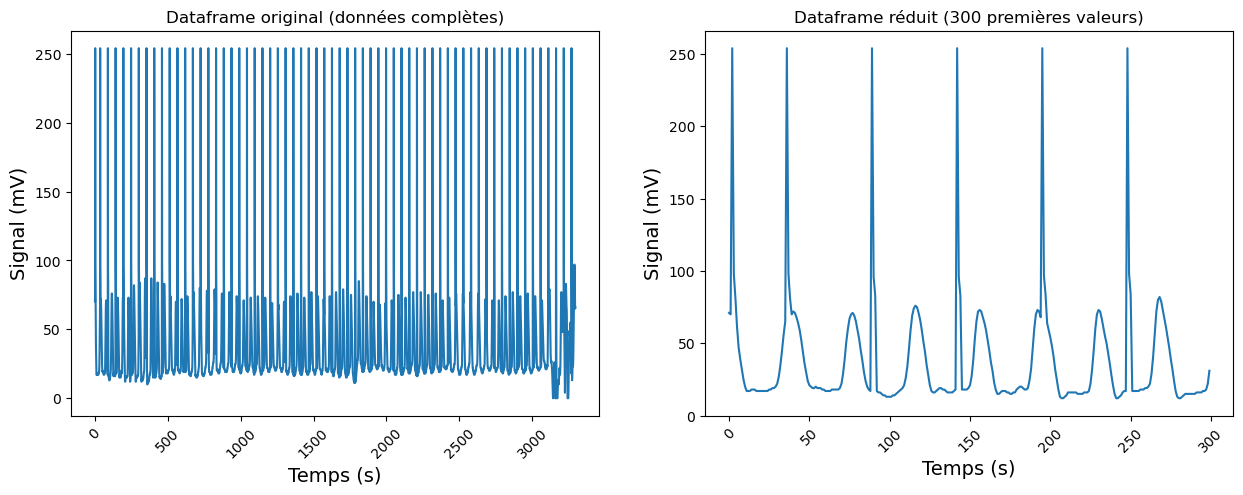

In [189]:
import matplotlib.pyplot as plt

df_crop = df.values.copy()[0:300] # On ne garde que les 300 premières valeurs pour le dataframe réduit

plt.subplots(1,2,figsize=(15,5))
plt.subplot(1,2,1)
plt.plot(df['data'], label='Dataframe original (données complètes)')
plt.xticks(rotation=45)
plt.ylabel('Signal (mV)',size=14)
plt.xlabel('Temps (s)',size=14)
plt.title('Dataframe original (données complètes)')
plt.subplot(1,2,2)
plt.plot(df_crop, label='Dataframe réduit (300 premières valeurs)')
plt.xticks(rotation=45)
plt.ylabel('Signal (mV)',size=14)
plt.xlabel('Temps (s)',size=14)
plt.title('Dataframe réduit (300 premières valeurs)')

In [190]:
print(*df_crop,sep=",") # permet d'afficher la liste des valeurs

[71],[70],[254],[98],[81],[61],[47],[39],[32],[25],[20],[17],[17],[17],[18],[18],[18],[17],[17],[17],[17],[17],[17],[17],[17],[18],[18],[19],[19],[20],[22],[27],[35],[45],[56],[65],[254],[98],[81],[70],[72],[71],[68],[64],[59],[52],[44],[36],[30],[24],[21],[20],[19],[19],[20],[19],[19],[19],[18],[18],[17],[17],[17],[17],[18],[18],[18],[18],[18],[19],[22],[29],[39],[51],[60],[67],[70],[71],[69],[65],[59],[53],[45],[38],[30],[24],[20],[18],[17],[254],[96],[83],[17],[16],[16],[15],[14],[14],[13],[13],[13],[13],[14],[14],[15],[16],[17],[18],[19],[21],[26],[34],[46],[59],[69],[74],[76],[75],[71],[66],[59],[51],[44],[35],[28],[21],[17],[16],[16],[17],[18],[19],[19],[18],[18],[17],[16],[16],[16],[16],[17],[18],[254],[96],[83],[18],[18],[18],[18],[19],[21],[27],[38],[53],[65],[72],[73],[72],[68],[64],[59],[52],[45],[37],[31],[23],[18],[15],[15],[16],[17],[17],[17],[16],[16],[15],[15],[16],[16],[18],[19],[20],[20],[19],[18],[18],[19],[24],[32],[46],[60],[70],[73],[72],[68],[254],[97],[84],[64],

In [191]:
import numpy as np

data = df['data'].values

# Liste des indices des différents signal tags
tagindex = np.where(data == 254)[0]

print("List of tag index values:", tagindex)
# Check if for the first tag index value, the signal value is indeed 254
#print(data[tagindex[0]][0])

print("Value at first tag index:", data[tagindex[0]])
print("Value sat_arr at first tag index:", data[tagindex[0]+1])
print("Value fc_arr at first tag index:", data[tagindex[0]+2])


# Define a set of empty lists to store the clinically useful information
sat_arr = data[tagindex+1] # Start with the first tag index value
fc_arr = data[tagindex+2] # Start with the first tag index value
data_arr = data.copy()
valuestoremove = np.concatenate((tagindex, tagindex+1, tagindex+2)) # Create an array of indices to remove from the data array
data_arr = np.delete(data_arr, valuestoremove) # Remove the clinically useful information from the data array

List of tag index values: [   2   36   89  142  195  248  301  354  407  460  513  566  619  672
  725  778  831  884  937  990 1043 1096 1149 1202 1255 1308 1361 1414
 1467 1520 1573 1626 1679 1732 1785 1838 1891 1944 1997 2050 2103 2156
 2209 2262 2315 2368 2421 2474 2527 2580 2633 2686 2739 2792 2845 2898
 2951 3004 3057 3110 3163 3216 3269]
Value at first tag index: 254
Value sat_arr at first tag index: 98
Value fc_arr at first tag index: 81


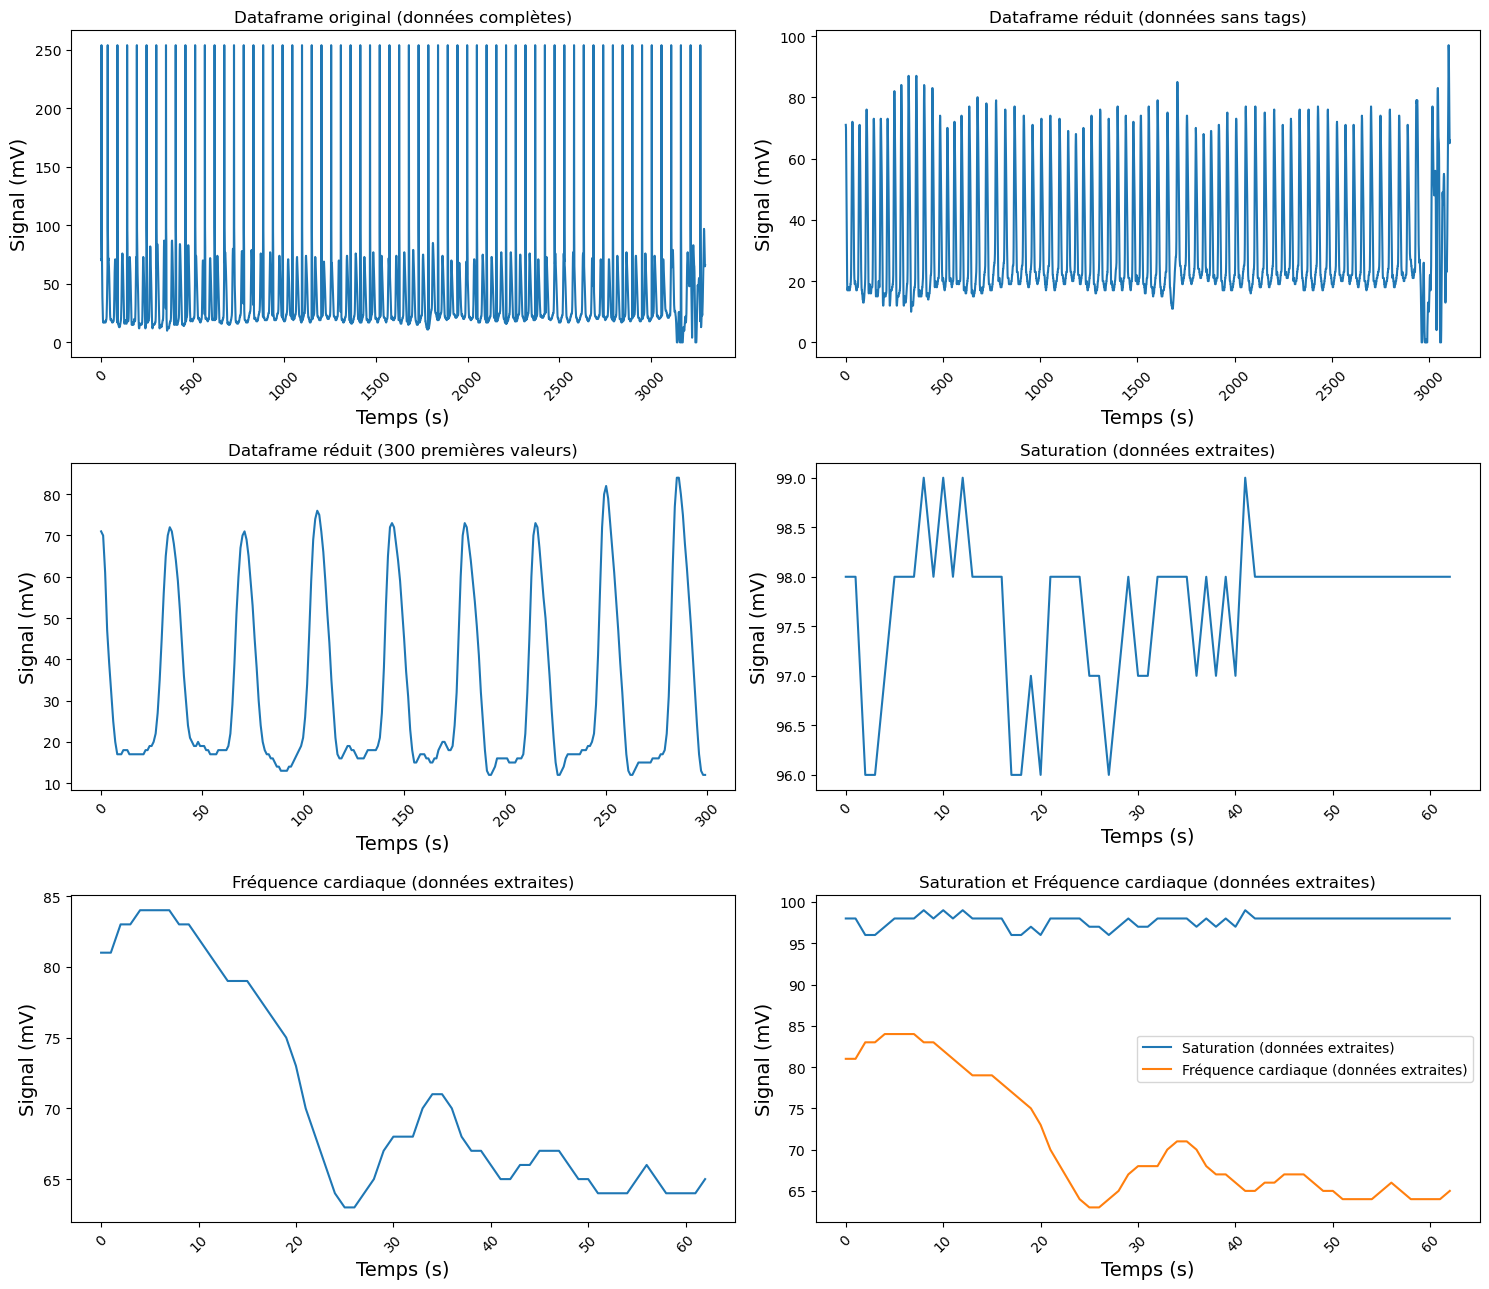

In [192]:
plt.subplots(3,2,figsize=(15,13))
plt.subplot(3,2,1)
plt.plot(data, label='Dataframe original (données complètes)')
plt.title('Dataframe original (données complètes)')
plt.xticks(rotation=45)
plt.ylabel('Signal (mV)',size=14)
plt.xlabel('Temps (s)',size=14)
plt.subplot(3,2,2)
plt.plot(data_arr, label='Dataframe réduit (données sans tags)')
plt.title('Dataframe réduit (données sans tags)')
plt.xticks(rotation=45)
plt.ylabel('Signal (mV)',size=14)
plt.xlabel('Temps (s)',size=14)
plt.subplot(3,2,3)
plt.plot(data_arr[0:300], label='Dataframe réduit (300 premières valeurs)')
plt.title('Dataframe réduit (300 premières valeurs)')
plt.xticks(rotation=45)
plt.ylabel('Signal (mV)',size=14)
plt.xlabel('Temps (s)',size=14)
plt.subplot(3,2,4)
plt.plot(sat_arr, label='Saturation (données extraites)')
plt.xticks(rotation=45)
plt.title('Saturation (données extraites)')
plt.ylabel('Signal (mV)',size=14)
plt.xlabel('Temps (s)',size=14)
plt.subplot(3,2,5)
plt.plot(fc_arr, label='Fréquence cardiaque (données extraites)')
plt.xticks(rotation=45)
plt.title('Fréquence cardiaque (données extraites)')
plt.ylabel('Signal (mV)',size=14)
plt.xlabel('Temps (s)',size=14)
plt.subplot(3,2,6)
plt.plot(sat_arr, label='Saturation (données extraites)')
plt.plot(fc_arr, label='Fréquence cardiaque (données extraites)')
plt.title('Saturation et Fréquence cardiaque (données extraites)')
plt.xticks(rotation=45)
plt.ylabel('Signal (mV)',size=14)
plt.xlabel('Temps (s)',size=14)
plt.legend()
plt.tight_layout()
plt.show()


## Exercice 5
-----------

On considère que l'âge moyen des étudiants inscrits au DQPRM est de 26 ans.

Après avoir affiché les données sous forme d'un box-plot, vérifier à partir du fichier `ages_DQPRM.csv` dans le dossier `data` que c'est bien le cas pour votre promo.

In [193]:
import pandas as pd

df = pd.read_csv('/Users/samy/Downloads/TP_Python/TP_Lina/data/ages_DQPRM.csv')
df = df.drop(columns=['Unnamed: 0'])
#change name of a colomn
df = df.rename(columns={'0': 'Age'})
df

,Age
0,29
1,25
2,25
3,24
4,29
5,26
6,27
7,27
8,32
9,26


In [194]:
import scipy.stats
import numpy as np

age_stats = scipy.stats.describe(df['Age'])
print(age_stats,'\n')
print("Age moyen :", age_stats.mean)
print("Age median :", np.median(df['Age']))

DescribeResult(nobs=45, minmax=(np.int64(20), np.int64(34)), mean=np.float64(26.133333333333333), variance=np.float64(9.072727272727272), skewness=np.float64(0.5115362254241266), kurtosis=np.float64(0.3402606816840108)) 

Age moyen : 26.133333333333333
Age median : 26.0


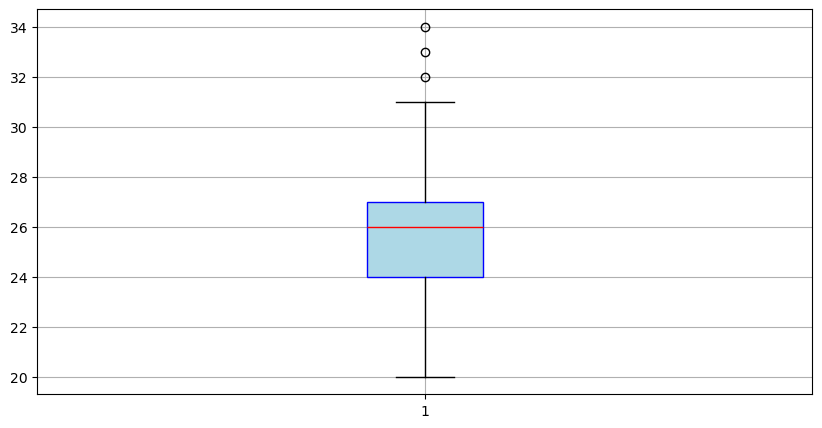

In [195]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.boxplot(df['Age'], vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue', color='blue'), medianprops=dict(color='red'))
plt.grid()
plt.show()

In [196]:
from scipy.stats import shapiro
stat, p = shapiro(df['Age'])
print('Statistique de test = %.3f, p-value = %.3f' % (stat, p))
if p > 0.05:
    print('La distribution des âges est normale (on ne rejette pas H0)')
else:
    print('La distribution des âges n\'est pas normale (on rejette H0)')



Statistique de test = 0.959, p-value = 0.115
La distribution des âges est normale (on ne rejette pas H0)


## Exercice 6
-----------

Le fichier `ages.csv` contenu dans le dossier `data` renseigne la taille (en $cm$) de 7 hommes et de 7 femmes.

**Question 1.** Regrouper les données selon le genre et les afficher sous forme de box-plots

**Question 2.** Vérifier que les échantillons homme/femme suivent une loi normale

**Question 3.** Vérifier que leur variance sont égales

**Question 4.** Comparer leur moyenne et conclure

In [197]:
import pandas as pd

df = pd.read_csv('/Users/samy/Downloads/TP_Python/TP_Lina/data/ages.csv')
df

,grouping,height
0,men,181.5
1,men,187.3
2,men,175.3
3,men,178.3
4,men,169.0
5,men,183.2
6,men,184.5
7,women,175.4
8,women,172.1
9,women,181.1


In [198]:
df.describe()

,height
count,14.000000
mean,175.464286
std,7.330611
min,165.200000
25%,169.325000
50%,175.350000
75%,181.400000
max,187.300000


In [199]:
df.groupby('grouping').describe()

height                                                           
          count        mean       std    min     25%    50%     75%    max
grouping                                                                  
men         7.0  179.871429  6.216836  169.0  176.80  181.5  183.85  187.3
women       7.0  171.057143  5.697619  165.2  166.65  170.3  173.75  181.1

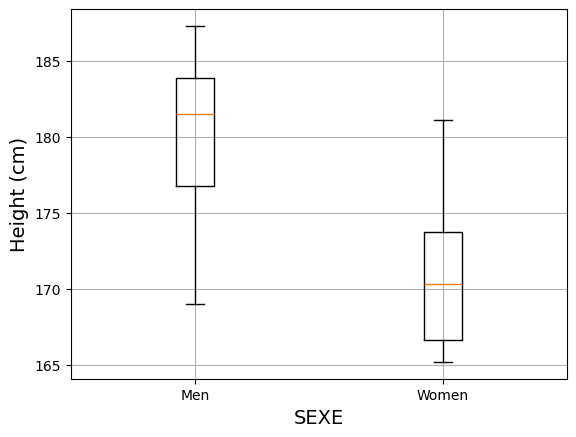

In [200]:
men = df.query('grouping == "men"')['height']
women = df.query('grouping == "women"')['height']
plt.boxplot([men, women])
plt.xticks([1, 2], ['Men', 'Women'])
plt.ylabel('Height (cm)',size=14)
plt.xlabel('SEXE',size=14)
plt.grid()
plt.show()

In [201]:
# check if the height distribution is normal for men and women using the Shapiro-Wilk test
from scipy.stats import shapiro

stat_men, p_value_men = shapiro(men)
stat_women, p_value_women = shapiro(women)

print(f"Men - Statistic: {stat_men}, P-value: {p_value_men}")
print(f"Women - Statistic: {stat_women}, P-value: {p_value_women}")





Men - Statistic: 0.9550847949572829, P-value: 0.7756238221291043
Women - Statistic: 0.9197604725000855, P-value: 0.4675335779005911


In [202]:
#check variance homogeneity using Levene's test
from scipy.stats import levene

stat , p_value = levene(men, women)

print(f"Levene's test - Statistic: {stat}, P-value: {p_value}")
print("Variance homogeneity test result:")
if p_value < 0.05:
    print("Variances are significantly different ")
else:
    print("Variances are not significantly different ")

Levene's test - Statistic: 0.026695150465104206, P-value: 0.8729335280501348
Variance homogeneity test result:
Variances are not significantly different 


In [203]:
#compare mean and conclude using t-test
from scipy.stats import ttest_ind

result = ttest_ind(men, women, equal_var=True)  # Assuming equal variances based on Levene's test result

print(f"t-test result - Statistic: {result.statistic}, P-value: {result.pvalue}")
print("Mean comparison test result:")
if result.pvalue < 0.05:
    print("Means are significantly different")
else:
    print("Means are not significantly different ")

t-test result - Statistic: 2.765444762721087, P-value: 0.017105701528166182
Mean comparison test result:
Means are significantly different


## Exercice 7
-----------

Les fumeurs ont un risque accru d’événements thrombotiques artériels (formation anormale de caillots), à l’origine notamment l’infarctus du myocarde. Les plaquettes sont des cellules sanguines périphériques qui sont impliquées dans la formation de ces caillots en s’agrégeant.

Une étude a été conduite chez 11 sujets volontaires sains pour comparer l’agrégation des plaquettes avant et après qu’ils aient fumé une cigarette.

A partir des données fournies dans le tableau suivant, déterminez si l’agrégation plaquettaire est modifiée après avoir fumé une cigarette ?  On suppose les conditions de validité du test vérifiées mais vous pourrez vous en assurer a posteriori.

<table>
   <caption>Agrégation plaquettaire</caption>
   <tr>
       <td>Avant</td>
       <td>25</td>
       <td>25</td>
       <td>27</td>
       <td>29</td>
       <td>30</td>
       <td>45</td>
       <td>51</td>
       <td>51</td>
       <td>57</td>
       <td>61</td>
       <td>68</td>
   </tr>
   <tr>
       <td>Après</td>
       <td>27</td>
       <td>29</td>
       <td>37</td>
       <td>45</td>
       <td>42</td>
       <td>60</td>
       <td>55</td>
       <td>78</td>
       <td>66</td>
       <td>60</td>
       <td>83</td>
   </tr>
</table>

In [204]:
import numpy as np
from scipy.stats import ttest_rel
data_mat = np.array([[25, 25, 27, 29, 30, 45, 51, 51, 57, 61,68],
                     [27, 29, 37, 45, 42, 60, 55, 78, 66, 60, 83]])
# determinaiton si les valeur plaquettaire sont deteriorer apres avoir fumé une cigarette

before = data_mat[0]
after = data_mat[1]

result = ttest_rel(before, after)
print(f"Paired t-test result - Statistic: {result.statistic}, P-value: {result.pvalue}")
if result.pvalue < 0.05:
    print("There is a significant difference in platelet counts before and after smoking.")
else:
    print("There is no significant difference in platelet counts before and after smoking.")



Paired t-test result - Statistic: -4.271608818429545, P-value: 0.0016328499219996706
There is a significant difference in platelet counts before and after smoking.


## Exercice 8 - Evolution de l’alcoolémie au cours du temps
-----------

Par définition, on appelle «alcoolémie» la concentration en $g/L$ d’éthanol ($CH_3CH_2OH$) dans le sang d’une personne. En France, la loi interdit à une personne de conduire si son alcoolémie est supérieure à $0.5\ g/L$.

On  se  propose  dans  cet  exercice  d’étudier  comment  varie  l’alcoolémie  d’une  personne  à  partir  du moment  où  elle  boit  deux bières (chacune  de  $50\ cL$  et à $6\ \%$), de façon notamment à savoir à quel moment elle pourra prendre le volant.

Il faut pour cela étudier deux mécanismes différents :
* l’**absorption de l’alcool dans le sang**, qui se fait par diffusion à travers les parois de l’estomac et de l’intestin grêle
* l’**élimination de l’alcool contenu dans le sang**, qui est effectuée essentiellement par  des  enzymes au niveau du foie (grâce à une réaction d’oxydation)

On va étudier chacun de ces deux processus séparément (dans les parties A et B), puis on combinera les deux dans la partie C.

### A - Absorption de l'alool à travers la paroi stomacale

On cherche dans ce paragraphe à étudier la loi cinétique modélisant le processus d'absorption, c’est à dire que l’on cherche à déterminer son ordre (si elle en possède un) et sa constante de vitesse $k$.

Pour cela, on réalise l’expérience suivante : on fait boire à un homme (initialement à jeun, c’est à dire l’estomac vide) une boisson alcoolisée de volume $V = 250\  mL$ contenant $1\ mole$ d’éthanol. On mesure alors  la  concentration  $c_1$ de l’éthanol dans  l’estomac  de  l’homme  en  fonction  du  temps.  

Les  résultats obtenus sont regroupés dans le tableau ci-dessous:

<table>
   <tr>
       <td>$t$ (en min)</td>
       <td>0</td>
       <td>1,73</td>
       <td>2,8</td>
       <td>5,5</td>
       <td>18</td>
       <td>22</td>
   </tr>
   <tr>
       <td>$c_1$ (en mol/L)</td>
       <td>à déterminer</td>
       <td>3,0</td>
       <td>2,5</td>
       <td>1,6</td>
       <td>0,2</td>
       <td>0,1</td>
   </tr>
</table>



**Question 1.** Utiliser  ces  données  pour  prouver  graphiquement que  la  réaction  d’absorption  de  l’alcool  dans  le  sang  suit  une  loi  cinétique  d’ordre  $1$,  et déterminer sa constante de vitesse $k_1$ (en précisant son unité).

NB. On fera appel pour cela à la fonction [linregress](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html) du sous-module `stats` de SciPy.

**Rappel**

Notons $c_1(t)$ la concentration de l’alcool dans l’estomac au cours du temps et $v_1=-\frac{dc_1}{dt}$ la vitesse d’absorption de l’alcool au niveau de la paroi de l’estomac.

Si la réaction est d’ordre 1, on aura aussi $v_1=kc_1(t)$ et $c_1(t)$ sera donc solution de l’équation différentielle :

$$\frac{dc_1(t)}{dt}+kc_1(t)= 0$$ qui se résout immédiatement en : $$c_1(t) =c_{1,0}.exp^{-kt}$$

où c$_{1,0}$ est la concentration initiale.

Ainsi, si la réaction est bien d’ordre 1, on aura :

$$ln(\frac{c_1(t)}{c_{1,0}})=-kt$$

In [205]:
from scipy.stats import linregress

def  calculate_inital_concentration(time, concentration,):
    slope, intercept, r_value, p_value, std_err = linregress(time, concentration)
    return intercept, slope, r_value, p_value, std_err

concentration_data = np.array([3, 3, 2.5, 1.6, 0.2, 0.1])
time_data = np.array([0, 1.73, 2.8, 5.5, 18, 22])


intercept, slope, r_value, p_value, std_err = calculate_inital_concentration(time_data, concentration_data)
# calcul quand t=0 pour retrouver c10
c10 = intercept

print("La concentration initiale d'alcool dans l'estomac est de", c10, "mol/L")

La concentration initiale d'alcool dans l'estomac est de 2.890283070033087 mol/L


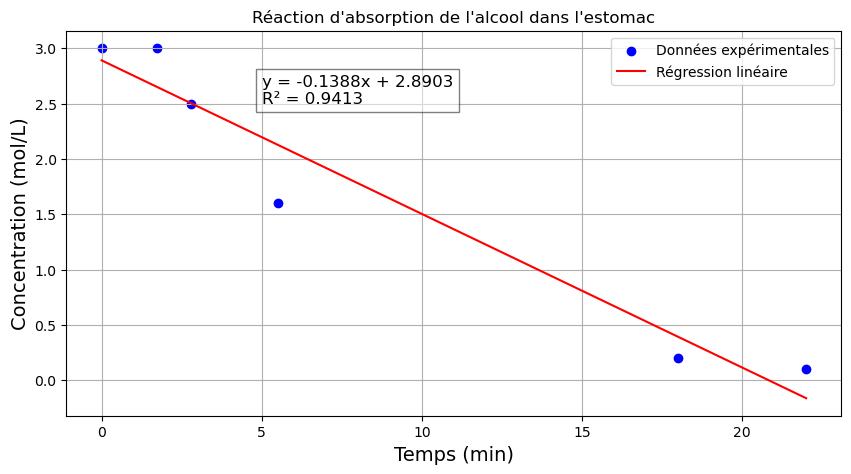

In [206]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats


plt.figure(figsize=(10,5))
plt.scatter(time_data, concentration_data, color='blue', label='Données expérimentales')
plt.plot(time_data, slope*time_data + intercept, color='red', label='Régression linéaire')
plt.title("Réaction d'absorption de l'alcool dans l'estomac")
plt.text(5, 2.5, f"y = {slope:.4f}x + {intercept:.4f}\nR² = {r_value**2:.4f}", fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
plt.xlabel("Temps (min)",size=14)
plt.ylabel("Concentration (mol/L)",size=14)
plt.legend()
plt.grid()  
plt.show()





**Question 2.** Calculer  la  valeur  (en  minutes)  du  temps  de demi-réaction $t_{1/2,1}$ de la réaction d’absorption  de l’alcool dans le sang.

In [207]:
k1 = -slope
tdemi1 = np.log(2)/k1
print("Le temps de demi-réaction vaut {:0.3f} min".format(tdemi1))

Le temps de demi-réaction vaut 4.996 min


### B - Oxydation de l’alcool dans le sang

Une fois que l’alcool est passé dans le sang, il est progressivement éliminé (surtout au niveau du foie) par une réaction d’oxydation qui le transforme en éthanal. Cette réaction a lieu grâce à une enzyme appelée alcool-déshydrogénase.

On cherche à présent à déterminer la loi de vitesse de cette réaction d’élimination de l’alcool.

Pour cela, on injecte directement (par voie veineuse) une certaine quantité d’alcool dans le sang d’un homme  et  on  mesure  par  des  prélèvements  successifs  l’évolution  de  la  concentration $c_2$ de l’alcool dans le sang de cet homme au cours du temps (on suppose que l’injection est quasi-instantanée et que la concentration de l’alcool dans le sang est la même en tout endroit du corps). On obtient les données du tableau suivant :

<table>
   <tr>
       <td>$t$ (en min)</td>
       <td>0</td>
       <td>120</td>
       <td>240</td>
       <td>360</td>
       <td>480</td>
       <td>600</td>
       <td>720</td>
   </tr>
   <tr>
       <td>$c_2$ (en mol/L)</td>
       <td>0,05</td>
       <td>0,0413</td>
       <td>0,0326</td>
       <td>0,0239</td>
       <td>0,0152</td>
       <td>0,0065</td>
       <td>0</td>
   </tr>
</table>

**Question 3.** A l’aide de ces données, déterminer l’ordre de cette réaction ainsi que sa constante de vitesse $𝑘_2$

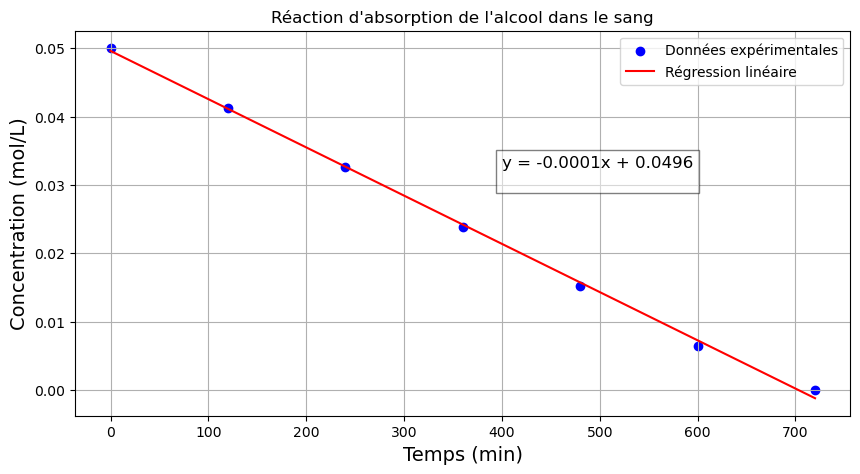

In [208]:
import numpy as np

time_data_blood = np.array([0, 120, 240, 360, 480, 600, 720])
concentration_data_blood = np.array([0.05, 0.0413, 0.0326, 0.0239, 0.0152, 0.0065, 0.0])



p, cov = np.polyfit(time_data_blood, concentration_data_blood, 1, cov=True)
slope_blood = p[0]
intercept_blood = p[1]

x = np.linspace(0, 720, 100)
y = slope_blood * x + intercept_blood
k2 = -slope_blood
plt.figure(figsize=(10,5))
plt.scatter(time_data_blood, concentration_data_blood, color='blue', label='Données expérimentales')
plt.plot(x, y, color='red', label='Régression linéaire')
plt.legend()
plt.text(400, 0.03, f"y = {slope_blood:.4f}x + {intercept_blood:.4f}\n", fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
plt.title("Réaction d'absorption de l'alcool dans le sang")
plt.xlabel("Temps (min)",size=14)
plt.ylabel("Concentration (mol/L)",size=14) 
plt.grid()
plt.show()


**Question 4.** Calculer  en  minutes  le  temps  de  demi  réaction $t_{1/2,2}$ de cette réaction et comparez le au temps de demi-réaction de l’absorption de l’alcool $t_{1/2,1}$. Commentaire?

In [209]:
y122 = concentration_data_blood.max()/2
print("La concentration maximale d'alcool dans le sang est de {:0.3f} mol/L".format(y122))
t122 = (y122 - intercept_blood)/slope_blood
print("Le temps pour atteindre la concentration maximale dans le sang est de {:0.3f} min".format(t122))

La concentration maximale d'alcool dans le sang est de 0.025 mol/L
Le temps pour atteindre la concentration maximale dans le sang est de 348.861 min


### C - Evolution de l’alcoolémie au cours du temps

Maintenant   que   l’on   connaît   les   lois   de   vitesse   de   la   réaction   d’absorption et   de   la   réaction d’élimination de l’alcool, on peut calculer comment évolue l’alcoolémie (concentration d’alcool dans le sang) au cours du temps, à partir du moment où une personne boit de l’alcool.

Notons $c$ la concentration (en $mol/L$) de l’alcool dans le sang et $v=\frac{dc}{dt}$ la vitesse à laquelle varie cette concentration.  On  note  également  $V_s$ le volume total du sang et  de  l’ensemble  compartiments hydriques  de  l’organisme (dans  lesquels se dissout l’alcool) et $V_e$ le volume de la boisson alcoolisée ingérée par la personne (qui correspond également au volume de son estomac puisqu’on considère que la personne était à jeun avant de boire).  

La concentration d'alcool dans le sang à l'instant $t$ s'écrit : $$c(t)=C_0\frac{V_e}{V_S}(1-e^{-k_1t})-k_2t$$ où $C_0$ est la concentration en alcool dans la boisson alcoolisée.

Lors d’une soirée, Alice boit deux bières, chacune de volume $V_0 = 50\ cL$ et de «degré alcoolique» $d =6\% $.

**Rappel** : le «degré alcoolique» correspond au pourcentage volumique d’éthanol dans la boisson, c’est à dire que: $d=\frac{V_{ethanol}}{V_{total}}$

**Question 5.** Sachant que  l’éthanol  a  une  masse  volumique $\rho_{eth}=0,79\ kg/L$, calculer  la  concentration  $C_0$ de l’éthanol dans la bière, en $g/L$ puis en $mol/L$ (on donne les masses molaires : $M_C = 12\ g/mol$, $M_H = 1,0\ g/mol$ et $M_O = 16\ g/mol$).

In [210]:
d = 0.06
rhoeth = 0.79
C0m = d * rhoeth * 1000 # en g/L
Meth = 46.07
C0 = C0m/Meth
print("La concentration massique de l'éthanol dans la bière est de {} g/L ".format(C0m))
print("La concentration molaire de l'éthanol dans la bière est de {:0.3f} mol/L ".format(C0))

La concentration massique de l'éthanol dans la bière est de 47.4 g/L 
La concentration molaire de l'éthanol dans la bière est de 1.029 mol/L 


**Question 6.**  Tracer   la   fonction $c(t)=C_0\frac{V_e}{V_S}(1-e^{-k_1t})-k_2t$ représentant l’évolution de la concentration en éthanol dans le sang d’Alice (en $mol/L$) à partir du moment où elle boit ses deux bières. On prendra $Vs = 40 L$ comme volume total du sang et des compartiments hydriques dans le corps d’Alice.

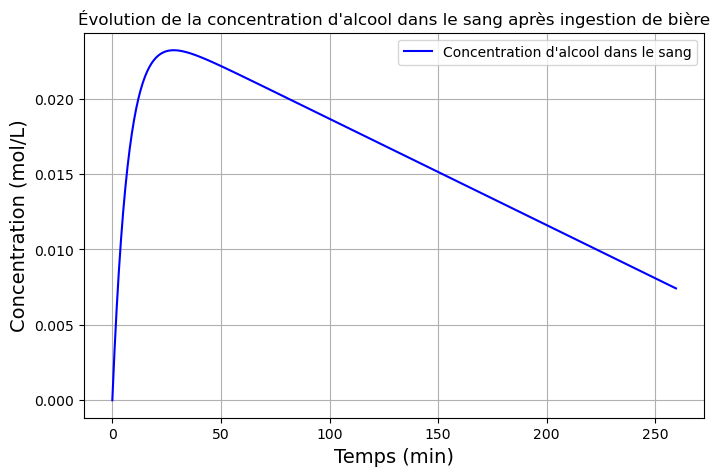

In [211]:
V0 = 0.5
Ve = 0.5 *2
Vs = 40
t = np.arange(0,260,0.5)
c = C0 * (Ve/Vs) * (1-np.exp(-k1*t))-k2*t
plt.figure(figsize=(8,5))
plt.plot(t, c, color='blue', label='Concentration d\'alcool dans le sang')
plt.title("Évolution de la concentration d'alcool dans le sang après ingestion de bière")
plt.xlabel("Temps (min)",size=14)
plt.ylabel("Concentration (mol/L)",size=14)
plt.grid()
plt.legend()
plt.show()

**Question 7.** Déterminer la valeur de concentration en éthanol maximale d'Alice

In [212]:
cmax = c.max()
print("La valeur de concentration en éthanol maximale d'Alice est de {:0.4f} mol/L".format(cmax))

La valeur de concentration en éthanol maximale d'Alice est de 0.0232 mol/L


**Question 8.** Déterminer l’instant  $t_{max}$ auquel la concentration en éthanol est maximale dans le sang d’Alice

In [213]:
tmax = t[np.argmax(c)]
print("L'instant auquel la concentration en éthanol est maximale dans le sang d’Alice est t = {:0.1f} min".format(tmax))


L'instant auquel la concentration en éthanol est maximale dans le sang d’Alice est t = 28.5 min


**Question 9.** Alice a-t-elle le droit de conduire à ce moment là?

In [214]:
Climmass = 0.5 # en g/L
Climmol = Climmass / 46.07 # en mol/L
print(Climmol)

0.010853049706967658


**Question 10.** Déterminer le temps au bout duquel Alice aura le droit de prendre le volant.

Le temps au bout duquel Alice aura le droit de prendre le volant est t = 211.0 min


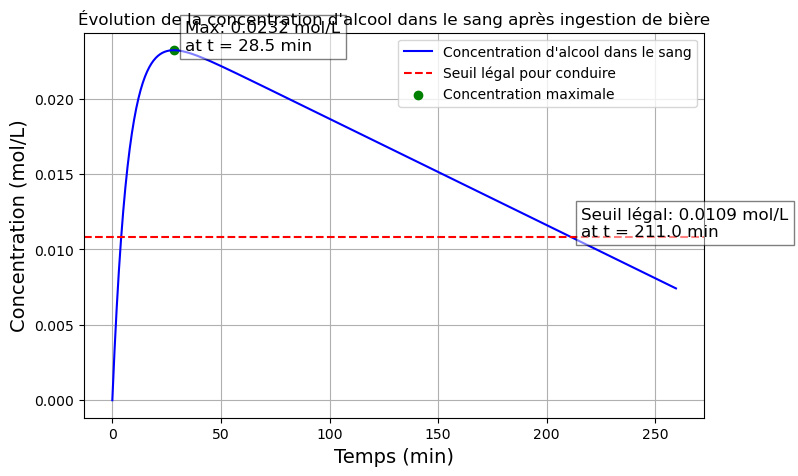

In [215]:
c_cond= c[np.argmax(c):] 
condition = c_cond < Climmol
t_cond = t[np.argmax(c):]   


tok = t_cond[condition][0] 
print("Le temps au bout duquel Alice aura le droit de prendre le volant est t = {:0.1f} min".format(tok))

# plot the concentration of alcohol in the blood over time with the maximum concentration point highlighted and the seuil of alcohol concentration for driving
plt.figure(figsize=(8,5))
plt.plot(t, c, color='blue', label='Concentration d\'alcool dans le sang')
plt.axhline(y=Climmol, color='red', linestyle='--', label='Seuil légal pour conduire')
plt.scatter(tmax, cmax, color='green', label='Concentration maximale')
plt.title("Évolution de la concentration d'alcool dans le sang après ingestion de bière")
plt.xlabel("Temps (min)",size=14)
plt.ylabel("Concentration (mol/L)",size=14)
plt.text(tmax + 5, cmax, f"Max: {cmax:.4f} mol/L\nat t = {tmax:.1f} min", fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
plt.text(tok + 5, Climmol, f"Seuil légal: {Climmol:.4f} mol/L\nat t = {tok:.1f} min", fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
plt.grid()
plt.legend()
plt.show()

## Exercice 9 - Affichage et manipulation d'une image TEP
-----------

**Question 1.** Charger l'image `1-PT.nii` contenue dans le sous-dossier `data`

**Question 2.**  Afficher les dimensions de cette image

**Question 3.**  Convertir l'image en un tableau (array) NumPy de la même taille

**Question 4.**  Afficher les dimensions de ce tableau

**Question 5.**  Identifier un plan de coupe sur lequel on voit nettement la tumeur qui se trouve dans le poumon (via 3D Slicer ou ITK-SNAP)

**Question 6.**  Rogner l'image afin d'effecteur un zoom sur cette tumeur et afficher le résultat

In [216]:
%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np
import SimpleITK as sitk
from ipywidgets import interact

In [217]:
image_pet = sitk.ReadImage("/Users/samy/Downloads/TP_Python/TP_Lina/data/1-PT.nii")

In [218]:
print("Taille de l'image CT (SimpleITK) = ",image_pet.GetSize())

Taille de l'image CT (SimpleITK) =  (200, 200, 543)


In [219]:
arr_image_pet = sitk.GetArrayFromImage(image_pet)

In [220]:
print("Taille du tableau (NumPy) correspondant = ",arr_image_pet.shape)

Taille du tableau (NumPy) correspondant =  (543, 200, 200)


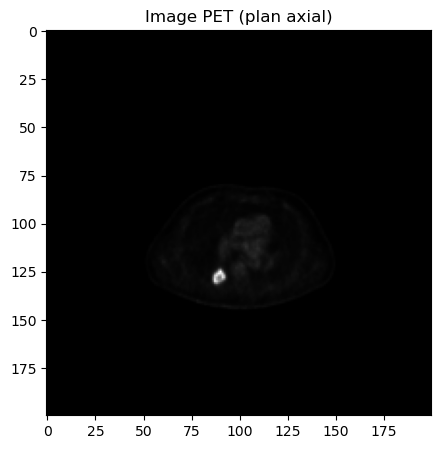

In [221]:
plt.figure(figsize=(10,5))
plt.imshow(arr_image_pet[337,:,:], cmap='gray')
plt.title("Image PET (plan axial)")
plt.show()
plan = 337


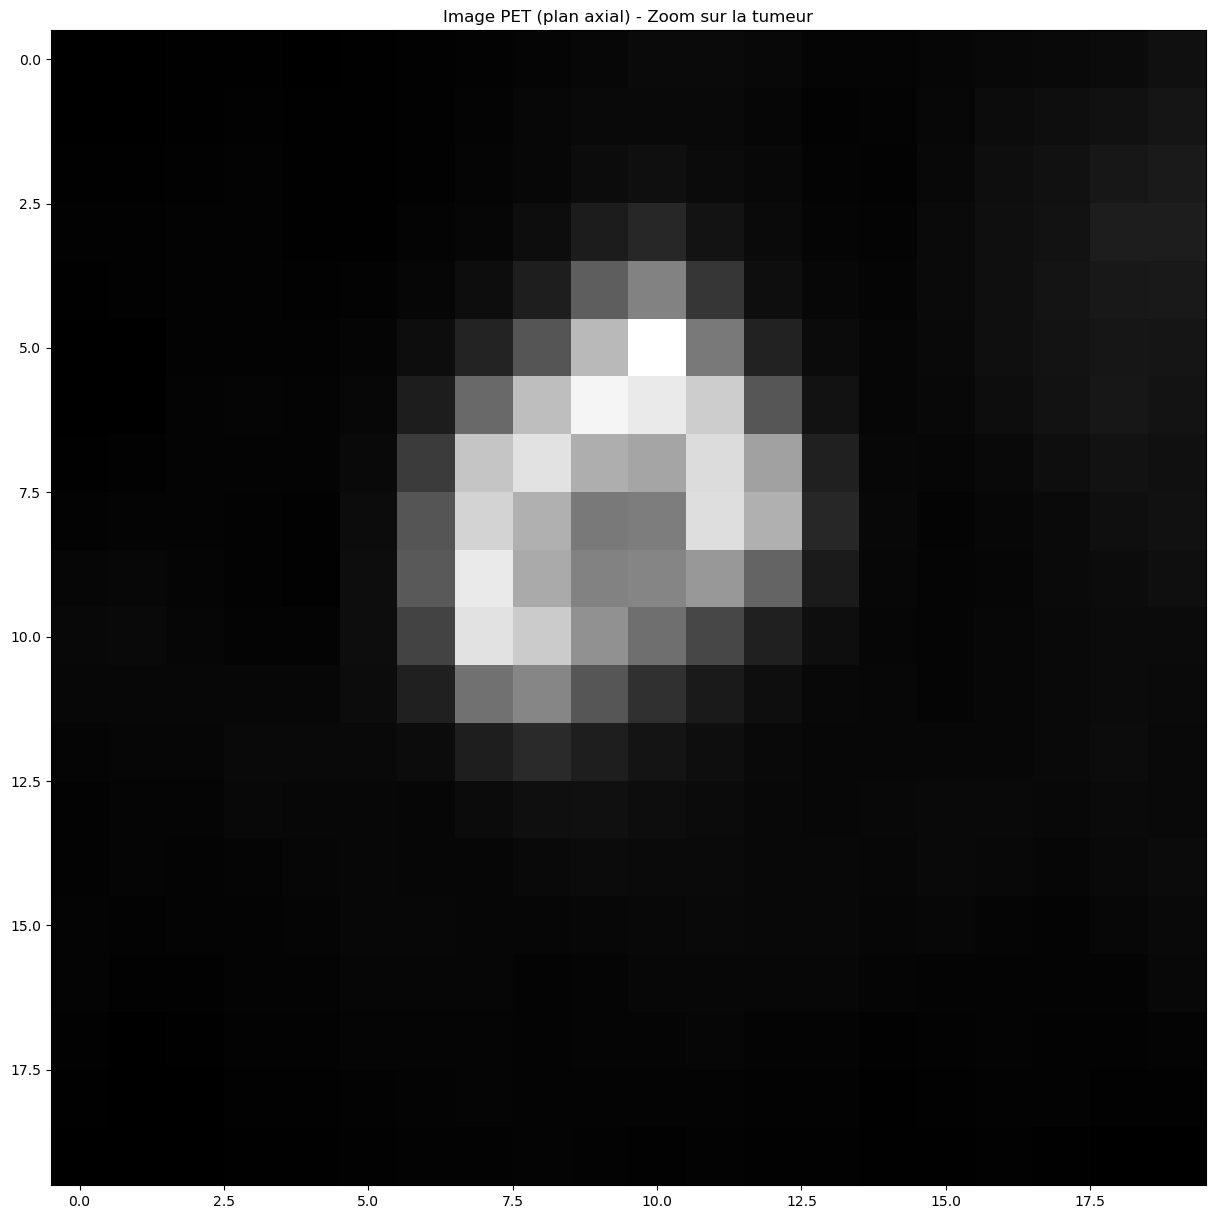

In [222]:
tumeur = arr_image_pet[plan,120:140,80:100]
plt.figure(figsize=(15,15))
plt.imshow(tumeur,cmap='gray')
plt.title("Image PET (plan axial) - Zoom sur la tumeur")
plt.show()

## Exercice 10 - Calcul de fonctions rénales relatives


---
**Question 1.** Réutiliser la méthode vue dans le notebook `3_Introduction-ROI.ipynb` pour définir un masque du bruit de fond (par exemple en sélectionnant une région rectangulaire au-dessus des deux reins)

**Question 2.** Appliquer ce masque sur l'image de scintigraphie rénale de départ (`PosteriorStatic001_DS.dcm` contenue dans le dossier `data`)

**Question 3.** Déterminer le nombre de coups moyen correspondant au du bruit de fond

**Question 4.** Utiliser ce nombre de coups moyen correspondant au bruit de fond et les nombres de coups moyens dans chacun des deux reins pour calculer les fonctions rénales relatives dont la formule retenue est la suivante (exemple pour le rein droit) :

$$
FRR_{droit}=100\times \frac{Coups_{rein\ droit} - Coups_{fond}}{(Coups_{rein\ droit} - Coups_{fond})+(Coups_{rein\ gauche} - Coups_{fond})}
$$


In [223]:
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk

In [224]:
rein = sitk.ReadImage('./data/PosteriorStatic001_DS.dcm')
rein_arr = sitk.GetArrayFromImage(rein).reshape(rein.GetWidth(),rein.GetHeight())
img = np.copy(rein_arr)

mask1 = np.zeros(img.shape)
mask2 = np.zeros(img.shape)

mask1[40:70,40:60] = 1
mask2[40:70,62:82] = 1

mask = mask1 + mask2

* Rein gauche

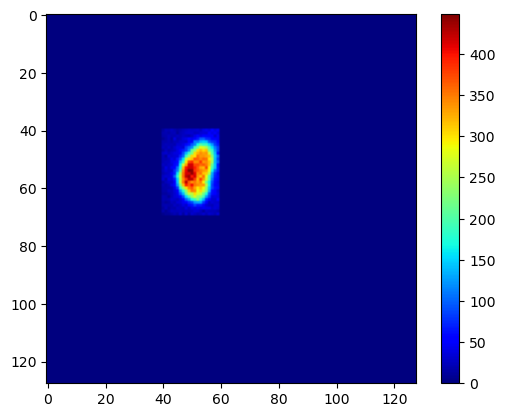

Nombre de coups total gauche : 76292.0
Nombre de pixels total gauche : 600.0
Nombre de coups moyen gauche = 127.15


In [225]:
rein_arr_segm1 = rein_arr * mask1 # Opération de mutliplication qui met à zéro ce qui est en dehors du masque
plt.imshow(rein_arr_segm1,cmap='jet')
plt.colorbar()
plt.show()
Ntot_g = rein_arr_segm1.sum() # Somme des intensités dans l'image
Nb_pixels_g = mask1.sum()  # Somme des intensités (0 ou 1) dans le masque ce qui donne ainsi sa taille (en nombre de pixels)
print("Nombre de coups total gauche :" , Ntot_g)
print("Nombre de pixels total gauche :" , Nb_pixels_g)
print("Nombre de coups moyen gauche = {:0.2f}".format(Ntot_g/Nb_pixels_g))

* Rein droit

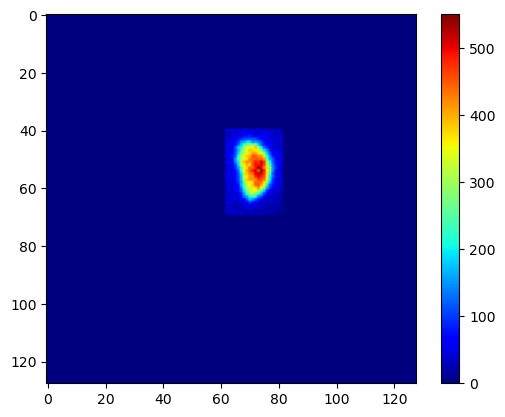

Nombre de coups total droit : 86777.0
Nombre de pixels total droit : 600.0
Nombre de coups moyen droit = 144.63


In [226]:
rein_arr_segm2 = rein_arr * mask2
plt.imshow(rein_arr_segm2,cmap='jet')
plt.colorbar()
plt.show()
Ntot_r = rein_arr_segm2.sum() # Somme des intensités dans l'image
Nb_pixels_r = mask2.sum()  # Somme des intensités (0 ou 1) dans le masque ce qui donne ainsi sa taille (en nombre de pixels)
print("Nombre de coups total droit :" , Ntot_r)
print("Nombre de pixels total droit :" , Nb_pixels_r)
print("Nombre de coups moyen droit = {:0.2f}".format(Ntot_r/Nb_pixels_r))

* Bruit de fond

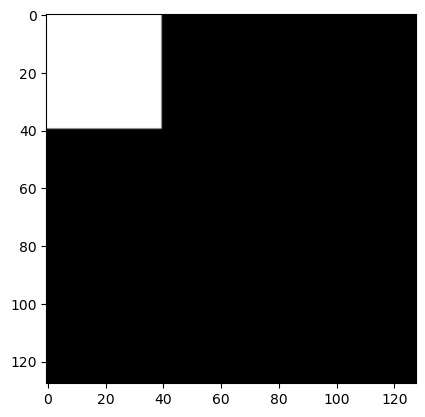

In [227]:
maskbg = np.zeros(img.shape)
maskbg[0:40,0:40] = 1
plt.imshow(maskbg, cmap='gray');

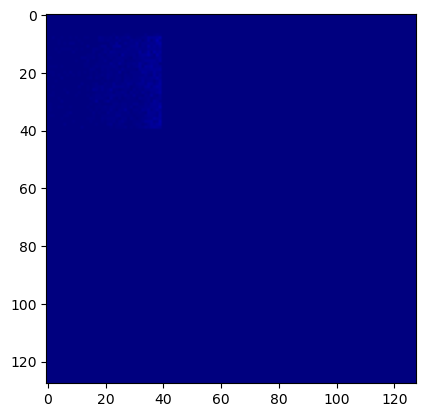

In [228]:
background = rein_arr * maskbg
plt.imshow(background, vmin=0, vmax=rein_arr.max(), cmap='jet')

In [229]:
Ntot_bg = np.sum(background)
Nb_pixels_bg = np.sum(maskbg)
print("Nombre de coups total :" , Ntot_bg)
print("Nombre de pixels total :" , Nb_pixels_bg)
print("Nombre de coups moyen = {:0.2f}".format(Ntot_bg/Nb_pixels_bg))

Nombre de coups total : 5342.0
Nombre de pixels total : 1600.0
Nombre de coups moyen = 3.34


$$
FRR_{droit}=100\times \frac{Coups_{rein\ droit} - Coups_{fond}}{(Coups_{rein\ droit} - Coups_{fond})+(Coups_{rein\ gauche} - Coups_{fond})}
$$

In [230]:
moyenne_gauche = Ntot_g / Nb_pixels_g
moyenne_droite = Ntot_r / Nb_pixels_r
moyenne_fond = Ntot_bg / Nb_pixels_bg

print("Gauche :", moyenne_gauche)
print("Droite :", moyenne_droite)
print("Fond   :", moyenne_fond)

gauche_corrige = moyenne_gauche - moyenne_fond
droite_corrige = moyenne_droite - moyenne_fond

FRR_d = 100 * droite_corrige / (
    droite_corrige + gauche_corrige
)

FRR_g = 100 * gauche_corrige / (
    droite_corrige + gauche_corrige
)

print(f"FRR droite : {FRR_d:.2f} %")
print(f"FRR gauche : {FRR_g:.2f} %")
print(f"Somme      : {FRR_d + FRR_g:.2f} %")

Gauche : 127.15333333333334
Droite : 144.62833333333333
Fond   : 3.33875
FRR droite : 53.30 %
FRR gauche : 46.70 %
Somme      : 100.00 %


## Exercice 11 - Votre ROI manuelle contre le contour clinique de référence

---

**Question 1 (prédiction).** Dice attendu, et effet attendu sur la FRR ?

**Question 2.** Vérifier le mapping label ↔ rectangle par comparaison directe.

**Question 3.** Dice/Jaccard/FN/FP/Hausdorff entre le rectangle et le contour de référence.

**Question 4.** FRR de référence (CSV) vs FRR du rectangle.

---

In [231]:
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk

rein = sitk.ReadImage('./data/rein/PosteriorStatic001_DS.nii')
rein_arr = sitk.GetArrayFromImage(rein).reshape(rein.GetWidth(), rein.GetHeight())

ref = sitk.ReadImage('./data/rein/output/maskTot.nii')
ref_arr = sitk.GetArrayFromImage(ref)

# vos rectangles de l'exercice 10
mask_reinD = np.zeros(rein_arr.shape)
mask_reinD[40:70, 62:82] = 1
mask_reinG = np.zeros(rein_arr.shape)
mask_reinG[40:70, 40:60] = 1

left_ref_mask = np.where(ref_arr == 2, 1, 0)
right_ref_mask = np.where(ref_arr == 1, 1, 0)

# dice score manually

dice_left = 2 * np.sum(mask_reinG * left_ref_mask) / (np.sum(mask_reinG) + np.sum(left_ref_mask))
dice_right = 2 * np.sum(mask_reinD * right_ref_mask) / (np.sum(mask_reinD) + np.sum(right_ref_mask))
print(f"Dice score for left kidney: {dice_left:.4f}")
print(f"Dice score for right kidney: {dice_right:.4f}")

#jaccard index
jaccard_left = np.sum(mask_reinG * left_ref_mask) / (np.sum(mask_reinG) + np.sum(left_ref_mask) - np.sum(mask_reinG * left_ref_mask))
jaccard_right = np.sum(mask_reinD * right_ref_mask) / (np.sum(mask_reinD) + np.sum(right_ref_mask) - np.sum(mask_reinD * right_ref_mask))
print(f"Jaccard index for left kidney: {jaccard_left:.4f}")
print(f"Jaccard index for right kidney: {jaccard_right:.4f}")

# hausdorff distance
from scipy.spatial.distance import directed_hausdorff

def distance_hausdorff(mask_a, mask_b):
    points_a = np.argwhere(mask_a > 0)
    points_b = np.argwhere(mask_b > 0)

    # Distance de A vers B
    distance_ab = directed_hausdorff(points_a, points_b)[0]

    # Distance de B vers A
    distance_ba = directed_hausdorff(points_b, points_a)[0]

    # Distance de Hausdorff symétrique
    return max(distance_ab, distance_ba)

hausdorff_left = distance_hausdorff(mask_reinG, left_ref_mask)
hausdorff_right = distance_hausdorff(mask_reinD, right_ref_mask)
print(f"Hausdorff distance for left kidney: {hausdorff_left:.4f}")
print(f"Hausdorff distance for right kidney: {hausdorff_right:.4f}")

#false negative rate
prediction = mask_reinG.astype(bool)
reference = left_ref_mask.astype(bool)

TP = np.sum(prediction & reference)
FP = np.sum(prediction & ~reference)
FN = np.sum(~prediction & reference)
TN = np.sum(~prediction & ~reference)


print("FP :", FP)
print("FN :", FN)
taux_faux_negatifs = FN / (FN + TP)
taux_faux_positifs = FP / (FP + TN)

print(f"Taux de faux négatifs pour le rein gauche : {taux_faux_negatifs:.4f}")
print(f"Taux de faux positifs pour le rein gauche : {taux_faux_positifs:.4f}")





Dice score for left kidney: 0.5472
Dice score for right kidney: 0.5437
Jaccard index for left kidney: 0.3767
Jaccard index for right kidney: 0.3733
Hausdorff distance for left kidney: 11.3137
Hausdorff distance for right kidney: 9.2195
FP : 374
FN : 0
Taux de faux négatifs pour le rein gauche : 0.0000
Taux de faux positifs pour le rein gauche : 0.0231


In [232]:
# FRR de référence à partir des CSV, vs votre FRR de l'exercice 10
# Les fichiers CSV sont tabulés (séparateur '\t'), pas des CSV standards à virgules.
def parse_csv_clinique(path):
    with open(path) as f:
        header = f.readline().rstrip('\n').split('\t')
        row = f.readline().rstrip('\n').split('\t')
    return dict(zip(header[1:], row[1:]))  # la 1re colonne est un simple index de ligne

ref_droit = parse_csv_clinique('./data/rein/RightKidney.csv')
ref_gauche = parse_csv_clinique('./data/rein/LeftKidney.csv')
ref_fond = parse_csv_clinique('./data/rein/Background.csv')

In [233]:
ref_fond

{'Volume (mm^3)': '10913.336151244097',
 'Volume (number of pixels)': '916.0',
 'Intensity mean': '45.51855895196506',
 'Intensity standard deviation': '17.973011198678833',
 'Intensity max': '110',
 'Intensity min': '28',
 'Intensity median': '39.0'}

In [234]:


FRR_ref_droit = 100*( ( float(ref_droit['Intensity mean'])- float(ref_fond['Intensity mean'])) / ((float(ref_gauche['Intensity mean'])-float(ref_fond['Intensity mean']))+(float(ref_droit['Intensity mean'])-float(ref_fond['Intensity mean'])) ))
FRR_ref_gauche = 100*( ( float(ref_gauche['Intensity mean'])- float(ref_fond['Intensity mean'])) / ((float(ref_droit['Intensity mean'])-float(ref_fond['Intensity mean']))+(float(ref_gauche['Intensity mean'])-float(ref_fond['Intensity mean'])) ))

print(f"FRR de référence pour le rein droit : {FRR_ref_droit:.2f}")
print(f"FRR de référence pour le rein gauche : {FRR_ref_gauche:.2f}")

FRR de référence pour le rein droit : 53.52
FRR de référence pour le rein gauche : 46.48


## Exercice 12 - Sensibilité du seuillage TEP

Reprend et prolonge le §7-9 de `5_TEP.ipynb` (segmentation de la tumeur par seuillage relatif du SUVmax, calcul du volume et de la TLG).

---

**Question 1 (prédiction).** Si l'on fait varier le seuil relatif de segmentation de 10 % à 50 % du SUVmax, comment pensez-vous que le **volume segmenté** et la **TLG** vont évoluer ? Lequel des deux vous semble le plus sensible au choix du seuil?

**Question 2.** Calculez, pour des seuils relatifs de 10 % à 50 % (pas de 2,5 %), le volume segmenté (mm³) et la TLG correspondants, à partir du volume TEP rogné autour de la tumeur du patient 4 (repartez du volume `IMAGE_cropped_np` construit en section 5 de `5_TEP.ipynb`). Tracez les deux courbes en fonction du seuil sur une même figure (deux axes y).

**Question 3.** Comparez le résultat obtenu à votre prédiction de la Question 1.

---

Il y a 5 série(s) présentes dans le dossier ./data/patient4
1.3.12.2.1107.5.1.4.11061.30000019101106360497600028758
1.3.12.2.1107.5.1.4.11061.30000019101106363026100031935
1.3.12.2.1107.5.8.15.101920.30000019112815175293800000226
1.3.12.2.1107.5.8.15.101920.30000019112815251995200000106
1.3.12.2.1107.5.8.15.101920.30000019112815253199500000055
0...CT-CT|2|TEP FDG : IMAGES->0-CT.nii-> OK
1...PT-PT|2|TEP FDG : IMAGES->1-PT.nii-> OK
2...SEG-SEG|1|TEP FDG : IMAGES
3...PT-PT|1|TEP FDG : IMAGES
4...PT-PT|1|TEP FDG : IMAGES
Units vaut BQML --> OK, l'image TEP est bien calibrée en Bq/mL
PET_SUV_ScaleFactor =  0.0004719280293222231
Series Time       : 152437.000000
Dose              : 268000000 Bq ou 268.0 MBq
Patient's Weight  : 90 kg
Half-life         : 6586.2 sec ou 109.77 min
Start Time        : 143044.000000

Facteur de conversion BqmL<->SUV = 0.0004719280293222231
Taille du pixel (mm) : : [4.0728302001953125, 4.0728302001953125]
Epaisseur de coupe (mm) : 2.0269999504089355
Facteur de conv

(np.float64(-0.5), np.float64(199.5), np.float64(199.5), np.float64(-0.5))

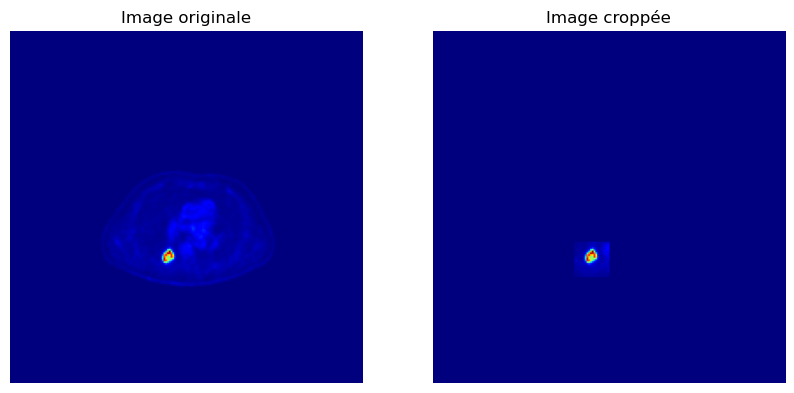

In [235]:
# Import required packages
import numpy as np
import sys, os, subprocess
import matplotlib.pyplot as plt

# Import SimpleITK
import SimpleITK as sitk

# Import Pydicom
import pydicom

# Define current working directory
pwd_dir = os.getcwd()
# Define input data directory
data_dir = './data/patient4'
# Define target directory
target_dir = os.path.join(pwd_dir,'output')
# If it doesn't exist, create it
if not os.path.exists(target_dir):
    os.makedirs(target_dir)
    
def read_DICOM_seriesID(dir_):
    sID = sitk.ImageSeriesReader.GetGDCMSeriesIDs(dir_)
    print("Il y a " + str(len(sID)) + " série(s) présentes dans le dossier " + dir_)
    print(*sID,sep='\n')

    return sID

def read_DICOM_files(series_ID_, dir_):
    for i, serie in enumerate(series_ID_):
        print(str(i) + "...", end = '')
        reader = sitk.ImageSeriesReader()
        series_file_names = sitk.ImageSeriesReader.GetGDCMSeriesFileNames(dir_,serie)
        reader.SetFileNames(series_file_names)
        ds = pydicom.filereader.dcmread(series_file_names[0])

        print(ds[0x0008,0x0060].value,end='-')
        print(ds.Modality,end='|')
        print(ds.pixel_array.itemsize,end='|')
        print(ds.ProcedureCodeSequence[0][0x0008,0x0104].value,end='')

        if ds.pixel_array.itemsize != 1: # itemsize() function returns the length of one array element in bytes (octets) 1 <=> (u)int8 et 2 <=> (u)int16
            if ds.Modality == 'PT': # S'il s'agit de TEP, on enregistre le dataset pour s'en resservir plus tard
                dataset = ds
            IMAGE = reader.Execute()
            chaine = str(i) + "-" + ds.Modality + ".nii"
            sitk.WriteImage(IMAGE,os.path.join(target_dir,chaine))
            print("->"+chaine+"-> OK",end='\n')
        else:
            print()

    return dataset

def compute_SUV_scale_factor(ds_):
    if ds_.Units == "BQML":
        print("Units vaut BQML --> OK, l'image TEP est bien calibrée en Bq/mL")
        RST = (ds_[0x0054,0x0016][0][0x0018,0x1072].value) # RadiopharmaceuticalStartTime
        RST = 3600 * int(RST[0:2]) + 60 * int(RST[2:4]) + int(RST[4:6]) # string to numerical value in sec
        RTD = (ds_[0x0054,0x0016][0][0x0018,0x1074].value) # RadionuclideTotalDose [Bq]
        RHL = (ds_[0x0054,0x0016][0][0x0018,0x1075].value) # RadionuclideHalfLife [s]
        ST  = (ds_[0x0008,0x0031].value)                   # SeriesTime
        ST  = 3600 * int(ST[0:2]) + 60 * int(ST[2:4]) + int(ST[4:6]) # string to numerical value in sec
        PW  = (ds_[0x0010,0x1030].value)                   # PatientWeight [kg]
        # RSD=(ds[0x0054,0x0016][0][0x0018,0x1078].value) #
        CD = RTD * pow(2,- (ST - RST) / RHL )             # CorrectedDose
        PET_SUV_ScaleFactor = PW * 1000 / CD # On multiplie par 1000 pour avoir le poids en g
        print("PET_SUV_ScaleFactor = ",PET_SUV_ScaleFactor)
        print("Series Time       : " + (ds_[0x0008,0x0031].value))
        print("Dose              : " + str(RTD) + " Bq ou " + str(RTD/1e6) + " MBq")
        print("Patient's Weight  : " + str(PW)+" kg")
        print("Half-life         : " + str(RHL) + " sec ou " + str(RHL/60) + " min")
        print("Start Time        : " + ds_[0x0054,0x0016][0][0x0018,0x1072].value)
        print()

    return PET_SUV_ScaleFactor

s_ID = read_DICOM_seriesID(data_dir)
dicom_files = read_DICOM_files(s_ID, data_dir)
SUV_factor = compute_SUV_scale_factor(dicom_files)

print("Facteur de conversion BqmL<->SUV = " + str(SUV_factor))

# On peut désormais directement travailler avec le volume TEP préalablement enregistré au format Nifti
IMAGE = sitk.ReadImage(os.path.join(target_dir,'1-PT.nii'))
sitk.WriteImage(IMAGE * SUV_factor,os.path.join(target_dir,'1-PT_SUV.nii'))
print('Taille du pixel (mm) : :', [IMAGE.GetSpacing()[0],IMAGE.GetSpacing()[1]])
print('Epaisseur de coupe (mm) :', IMAGE.GetSpacing()[2])

# Calcul du volume (en mm3) du voxel directement
vox2vol_Factor = IMAGE.GetSpacing()[0] * IMAGE.GetSpacing()[1] * IMAGE.GetSpacing()[2]
print("Facteur de conversion voxel<->mm3 = " + str(vox2vol_Factor) + " (mm3/voxel)")

tumor_center = [90,130,337] # Définition du centre de la tumeur
nb_slices_to_crop = 10      # Demi-taille de la boîte englobante
TC , NS = tumor_center, nb_slices_to_crop
# Pour faciliter la lecture des lignes suivantes, on crée un nouveau volume 'croped'
IMAGE_cropped = IMAGE   # Sur la base du volume TEP initial
IMAGE_cropped_np = sitk.GetArrayFromImage(IMAGE_cropped)  # Copie du volume TEP initial

# On va mettre à 0 ce qui est en dehors de notre boîte englobante
# Attention à l'indexation des arrays NumPy dont l'ordre est inversé par rapport à l'image SimpleITK de départ
IMAGE_cropped_np[:,:,TC[0] + NS:] = 0
IMAGE_cropped_np[:,:,:TC[0] - NS] = 0

IMAGE_cropped_np[:,TC[1] + NS:,:] = 0
IMAGE_cropped_np[:,:TC[1] - NS,:] = 0

IMAGE_cropped_np[TC[2] + NS:,:,:] = 0
IMAGE_cropped_np[:TC[2] - NS,:,:] = 0

plt.subplots(1,2,figsize=(10,5))
plt.subplot(121)
plt.imshow(sitk.GetArrayFromImage(IMAGE)[TC[2],:,:],cmap='jet')
plt.title('Image originale')
plt.axis('off')
plt.subplot(122)
plt.imshow(IMAGE_cropped_np[TC[2],:,:],cmap='jet')
plt.title('Image croppée')
plt.axis('off')

Mesures obtenues en utilisant le volume TEP rogné (cropped)
Valeur d'intensité maximale : 61027.0224 Bq/mL
Vérifier cette valeur en ouvrant le volume 1-PT.nii dans ITK-SNAP
En utilisant l'inspecteur (menu Tools>Image Contrast>Contrast Adjustement...  
ou [Ctrl]+[I] puis l'onglet contraste qui donne la valeur maximale (en Bq/mL)
Voxel le + intense : 61027.0224 Bq/mL <=> 28.800362416635163 SUVmax
Valeur max   :  61027.0224  Bq/mL
Valeur seuil :  9154.05336 Bq/mL  <=>  4.3200543624952745  SUV
Fichier SEG.nii écrit.. OK
Essayer d'autres seuils de segmentation [0;1] (0,40 est très sélectif, tenter 0,15 pour le volume rogne et 0,05 pour le volume entier)
Essayer sur l'image TEP entiere et sur l'image rognée (étape 6 mettre total_flag = False)
Ne pas oublier dans le quart inferieur gauche d'ITK-SNAP de cliquer sur 'update' pour visualiser
la segmentation en 3D
Seuil : 15 %
601 voxels de segmentation / 601 voxels
601 voxels <=> 20207.883001975446 mm3
Comparer ces valeurs (en voxels et en mm3)


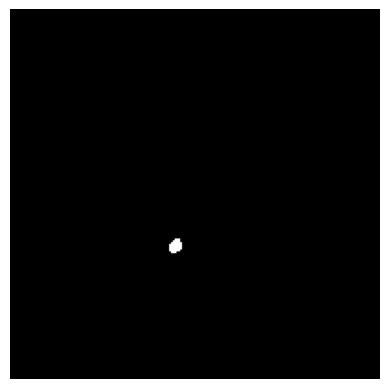

In [236]:
total_flag = False     # Sélectionne si on travaillera sur le volume TEP entier (total_flag=True)
                       # ou si on travaillera sur le volume rogné (total_flag=False)

if total_flag:
    print("Mesures obtenues en utilisant tout le volume TEP")
    IMAGE_np = sitk.GetArrayFromImage(IMAGE)
else:
    print("Mesures obtenues en utilisant le volume TEP rogné (cropped)")
    IMAGE_np = IMAGE_cropped_np

IMAGE_np_max = IMAGE_np.max()
print("Valeur d'intensité maximale : " + str(IMAGE_np_max) + " Bq/mL")
print("Vérifier cette valeur en ouvrant le volume 1-PT.nii dans ITK-SNAP")
print("En utilisant l'inspecteur (menu Tools>Image Contrast>Contrast Adjustement...  ")
print("ou [Ctrl]+[I] puis l'onglet contraste qui donne la valeur maximale (en Bq/mL)")
# Conversion Bq/mL<->SUV
IMAGE_np_max_SUV = IMAGE_np_max * SUV_factor
print("Voxel le + intense : " + str(IMAGE_np_max) + " Bq/mL <=> " + \
      str(IMAGE_np_max_SUV) + " SUVmax")

seuil = 0.15

IMAGE_np_seuil = seuil * IMAGE_np.max()    # Calcul du seuil relatif pour cette image
SEG_size = IMAGE.GetSize()                 # Récupère la taille de l'image, ce sera la taille de l'image segmentation
SEG = sitk.Image(SEG_size,sitk.sitkUInt8)  # Crée une image segmentation (masque binaire) 8 bits suffisent
               # Copie pixel_size, spacing , etc

SEG_mask = IMAGE_np >= IMAGE_np_seuil  # Masque qui correspond a notre condition de segmentation
plt.imshow(SEG_mask[TC[2],:,:],cmap='gray')
plt.axis('off')
print("Valeur max   : ",IMAGE_np.max()," Bq/mL")
print("Valeur seuil : ",IMAGE_np_seuil, "Bq/mL ",end = "")
print(" <=> ",IMAGE_np_seuil * SUV_factor," SUV")

# Créer l'objet sitk de segmentation a partir du masque (que l'on multiplie a une matrice de 'ones')
SEG = sitk.GetImageFromArray(np.multiply(SEG_mask,np.ones(SEG_mask.shape)))
SEG.CopyInformation(IMAGE)                 # Copie pixel_size, spacing , etc TRES IMPORTANT

# Sauvegarder la segmentation dans un fichier SEG.nii
sitk.WriteImage(SEG,os.path.join(target_dir,"SEG.nii"))
print("Fichier SEG.nii écrit.. OK")

print("Essayer d'autres seuils de segmentation [0;1] (0,40 est très sélectif, tenter 0,15 pour le volume rogne et 0,05 pour le volume entier)")
print("Essayer sur l'image TEP entiere et sur l'image rognée (étape 6 mettre total_flag = False)")
print("Ne pas oublier dans le quart inferieur gauche d'ITK-SNAP de cliquer sur 'update' pour visualiser")
print("la segmentation en 3D")
seg_nb_vox = SEG_mask.sum() #len(SEG_mask[SEG_mask==1])
seg_nb_mm3 = seg_nb_vox * vox2vol_Factor
print("Seuil :",str(int(100*seuil))+" %")
print(seg_nb_vox,"voxels de segmentation /",seg_nb_vox,"voxels")
print(str(seg_nb_vox) + " voxels <=> " + str(seg_nb_mm3) + " mm3")
print("Comparer ces valeurs (en voxels et en mm3)")
print("aux valeurs donnees dans ITK-SNAP (menu Segmentation>Volumes and Statistics...)")

In [237]:
import numpy as np
import matplotlib.pyplot as plt

# Réutilisez ici le volume SUV rogné autour de la tumeur (section 5 et 6 de 5_TEP.ipynb)
# et le facteur de conversion voxel -> mm3 (vox2vol_Factor)
IMAGE_np = IMAGE_cropped_np        # volume rogné, en unités SUV (array NumPy)
voxel_volume_mm3 = np.prod(IMAGE.GetSpacing())

seg_nb_vox = SEG_mask.sum()
seg_volume_mm3 = seg_nb_vox * voxel_volume_mm3
seg_volume_ml = seg_volume_mm3 / 1000

print("Volume d'un voxel :", voxel_volume_mm3, "mm³")
print("Volume segmenté :", seg_volume_mm3, "mm³")
print("Volume segmenté :", seg_volume_ml, "mL")

Volume d'un voxel : 33.623765394301905 mm³
Volume segmenté : 20207.883001975446 mm³
Volume segmenté : 20.207883001975446 mL


In [238]:
seuils = np.arange(0.10, 0.525, 0.025)

volumes_mm3 = []
tlgs = []

# Dans ton carnet, IMAGE_cropped_np est encore en Bq/mL
image_suv = IMAGE_cropped_np.astype(np.float64) * SUV_factor

suv_max = image_suv.max()
voxel_volume_mm3 = np.prod(IMAGE.GetSpacing())

for seuil in seuils:
    mask = image_suv >= seuil * suv_max

    nb_voxels = mask.sum()

    volume_mm3 = nb_voxels * voxel_volume_mm3
    volume_ml = volume_mm3 / 1000

    suv_mean = image_suv[mask].mean()
    tlg = suv_mean * volume_ml

    volumes_mm3.append(volume_mm3)
    tlgs.append(tlg)

print("Nombre de seuils :", len(seuils))
print("Nombre de volumes :", len(volumes_mm3))
print("Nombre de TLG :", len(tlgs))

Nombre de seuils : 17
Nombre de volumes : 17
Nombre de TLG : 17


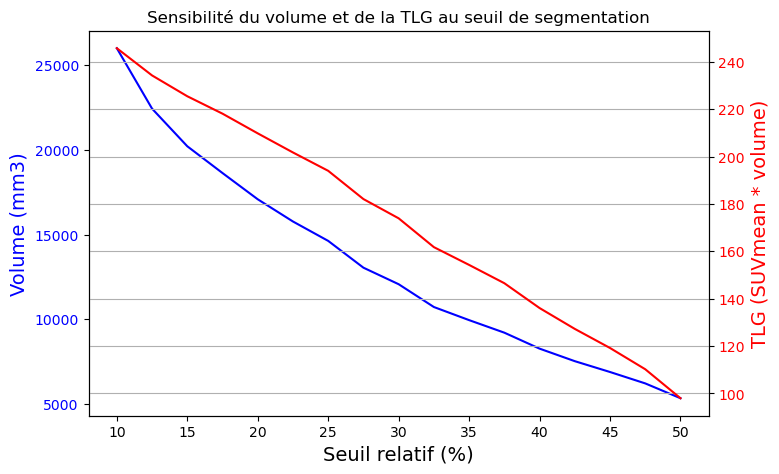

In [239]:
fig, ax1 = plt.subplots(figsize=(8, 5))
plt.title("Sensibilité du volume et de la TLG au seuil de segmentation")
plt.xlabel("Seuil relatif (%)",size=14)
plt.ylabel("Volume (mm3)",size=14)
ax1.plot(seuils*100, volumes_mm3, color='blue', label='Volume (mm3)')
ax1.set_ylabel("Volume (mm3)", color='blue',size=14)
ax1.tick_params(axis='y', labelcolor='blue')    
ax2 = ax1.twinx()
ax2.plot(seuils*100, tlgs, color='red', label='TLG (SUVmean * volume)')
ax2.set_ylabel("TLG (SUVmean * volume)", color='red',size=14)
ax2.tick_params(axis='y', labelcolor='red')
plt.grid()
plt.show()

## Exercice 13 - Trois façons de calculer des statistiques par label

Reprend le §2.4 de `3_Introduction-ROI.ipynb` (`sitk.LabelIntensityStatisticsImageFilter` appliqué à `0-CT.nii` et `segmentation.nii.gz`).

---

**Question 1.** Écrivez une fonction `stats_boucle(arr_img, arr_lab, label)` avec des boucles `for` explicites.

**Question 2.** Écrivez une fonction `stats_vectorise(arr_img, arr_lab, label)` avec des opérations NumPy vectorisées.

**Question 3.** Vérifiez que les trois méthodes donnent le même résultat.

**Question 4.** Chronométrez les trois approches sur une seule coupe 2D.

**Question 5.** Classez les trois approches par ordre de rapidité et expliquez l'écart.

---

In [240]:
import time
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt

img_ct = sitk.ReadImage('./data/0-CT.nii')
arr_img_ct = sitk.GetArrayFromImage(img_ct)
img_lab = sitk.ReadImage('./data/segmentation.nii.gz')
arr_img_lab = sitk.GetArrayFromImage(img_lab)

coupe = 458
arr_img_2d = arr_img_ct[coupe]
arr_lab_2d = arr_img_lab[coupe]

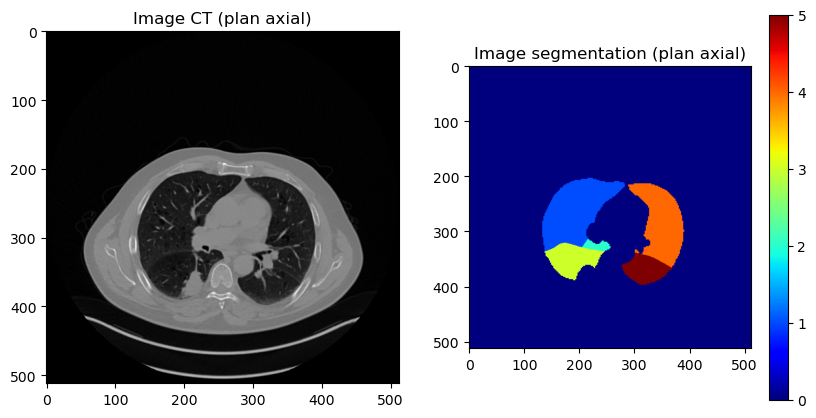

In [241]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(arr_img_2d, cmap='gray')
plt.title("Image CT (plan axial)")
plt.subplot(1,2,2)
plt.imshow(arr_lab_2d, cmap='jet')
plt.colorbar()
plt.title("Image segmentation (plan axial)")
plt.show()

In [242]:
def stats_boucle(arr_img, arr_lab, label):
    somme = 0.0
    nb_voxels = 0

    # calcul de la moyenne
    for i in range(arr_img.shape[0]):
        for j in range(arr_img.shape[1]):
            if arr_lab[i, j] == label:
                valeur = float(arr_img[i, j])
                somme += valeur
                nb_voxels += 1

    if nb_voxels == 0:
        return 0.0, 0.0, 0

    moyenne = somme / nb_voxels

    # calcul de l'écart-type
    somme_ecarts_carres = 0.0

    for i in range(arr_img.shape[0]):
        for j in range(arr_img.shape[1]):
            if arr_lab[i, j] == label:
                valeur = float(arr_img[i, j])
                ecart = valeur - moyenne
                somme_ecarts_carres += ecart ** 2

    if nb_voxels > 1:
        variance = somme_ecarts_carres / (nb_voxels - 1)
        ecart_type = np.sqrt(variance)
    else:
        ecart_type = 0.0

    return moyenne, ecart_type, nb_voxels

In [243]:
# implémentez stats_vectorise uniquement avec des opérations NumPy vectorisées

def stats_vectorise(arr_img, arr_lab, label):
    valeurs = arr_img[arr_lab == label]
    return (valeurs.mean(), valeurs.std(), valeurs.size) if valeurs.size else (0.0, 0.0, 0)

In [244]:
label_test = 1 # liver

m1, s1,_1 = stats_boucle(arr_img_2d, arr_lab_2d, label_test)
m2, s2,_ = stats_vectorise(arr_img_2d, arr_lab_2d, label_test)

stats_sitk = sitk.LabelIntensityStatisticsImageFilter()
stats_sitk.Execute(sitk.GetImageFromArray(arr_lab_2d), sitk.GetImageFromArray(arr_img_2d))   # attention: LabelIntensityStatisticsImageFilter attend des images sitk, pas des arrays
m3 = stats_sitk.GetMean(label_test)
s3 = stats_sitk.GetStandardDeviation(label_test)
print("Comparaison des résultats pour le label", label_test)

print("Boucle     :", m1, s1)
print("Vectorisé  :", m2, s2)
print("sitk filter:", m3, s3)

Comparaison des résultats pour le label 1
Boucle     : -759.7068090787717 152.83404104080998
Vectorisé  : -759.7068090787717 152.8272391964823
sitk filter: -759.7068090787717 152.83404104080995


In [245]:
#  chronométrage (utilisez %timeit -o pour récupérer les temps dans des variables)
t_boucle = %timeit -o stats_boucle(arr_img_2d, arr_lab_2d, label_test)
print("Temps boucle     :", t_boucle.best, "s")
t_vectorise = %timeit -o stats_vectorise(arr_img_2d, arr_lab_2d, label_test)
print("Temps vectorisé  :", t_vectorise.best, "s")  


40.6 ms ± 1.9 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
Temps boucle     : 0.038302662502974275 s
86.5 μs ± 3.31 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
Temps vectorisé  : 8.353954160120338e-05 s


## Exercice 14 - Problème de variance

Le code ci-dessous prétend recalculer "à la main" la variance de l'image de scintigraphie rénale, pour la comparer à `arr.var()` de NumPy. **Exécutez-le d'abord tel quel, sans le corriger.**

---

In [252]:
import numpy as np
import SimpleITK as sitk

rein = sitk.ReadImage('./data/rein/PosteriorStatic001_DS.nii')
rein_arr = sitk.GetArrayFromImage(rein).reshape(rein.GetWidth(), rein.GetHeight())

def variance_maison(arr):
    n = arr.size
    somme = arr.sum()
    somme_carres = (np.float32(arr) ** 2).sum()   # E[X^2]
    moyenne = somme / n
    return somme_carres / n - moyenne ** 2   # E[X^2] - E[X]^2

print("Variance (maison) :", variance_maison(rein_arr))
print("Variance (NumPy)  :", rein_arr.var())
print("Are the results equal? delta of ? ", np.isclose(variance_maison(rein_arr), rein_arr.var(), rtol=1e-10, atol=1e-6), "delta = ", np.abs(variance_maison(rein_arr) - rein_arr.var()))

Variance (maison) : 2608.382670696825
Variance (NumPy)  : 2608.382731731981
Are the results equal? delta of ?  False delta =  6.103515625e-05


---

**Question 1.** Le résultat de `variance_maison` est-il cohérent avec celui de `rein_arr.var()` ? Quantifiez l'écart.

**Question 2.** Diagnostiquez la cause du problème.

**Question 3.** Corrigez `variance_maison` pour qu'elle donne le même résultat que `rein_arr.var()` à 1e-6 près.

---

## Exercice 15 - Les références

---

**Question 1 (prédiction).** `b = a[2:5]` puis `b[0]=999` ; `c = a[a>5]` puis `c[0]=999` : `a` est-il affecté dans chaque cas ?

**Question 2.** Vérification avec `np.shares_memory`.

**Question 3.** Bug réel sur le volume CT.

**Question 4.** Coût mesuré copie vs vue.

**Question 5.** Vue ou copie, en pratique ?

**Question 6.** Accumulation de copies dans un pipeline : mesurer le pic mémoire réel.

---

In [253]:
import numpy as np

a = np.arange(10)
print("a =", a)

a = [0 1 2 3 4 5 6 7 8 9]


In [254]:
#  vérification sur le petit array
a = np.arange(10)
b = a[2:5]
b[0] = 999
print("apres modif de b : a =", a, " | shares_memory(a,b) =", np.shares_memory(a, b))

a = np.arange(10)
c = a[a > 5]
c[0] = 999
print("apres modif de c : a =", a, " | shares_memory(a,c) =", np.shares_memory(a, c))

a = np.arange(10)
d = a[[1, 2, 3]]
print("shares_memory(a,d) =", np.shares_memory(a, d))

apres modif de b : a = [  0   1 999   3   4   5   6   7   8   9]  | shares_memory(a,b) = True
apres modif de c : a = [0 1 2 3 4 5 6 7 8 9]  | shares_memory(a,c) = False
shares_memory(a,d) = False


In [255]:
# Question 3 : reproduction du bug sur le volume CT réel, puis correction
import SimpleITK as sitk

img_ct = sitk.ReadImage('./data/0-CT.nii')
arr_ct = sitk.GetArrayFromImage(img_ct)

z = arr_ct.shape[0] // 2
arr_ct_slice = arr_ct[z, :, :]



In [256]:
# Question 4 : mesure du coût copie vs vue
import numpy as np
c = np.arange(1000000)

%timeit c_copy = c.copy()
%timeit c_view = c.view()
# cost in memory
import sys
c_copy = c.copy()
c_view = c.view()
print("Size of c_copy:", sys.getsizeof(c_copy), "bytes")
print("Size of c_view:", sys.getsizeof(c_view), "bytes")

393 μs ± 21.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
35.5 ns ± 0.507 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)
Size of c_copy: 8000112 bytes
Size of c_view: 112 bytes


In [257]:
# Question 6 : pipeline naif
# Objectif : un petit pretraitement HU (clip min/max) + conversion en float32,
# en copiant "par prudence" a chaque etape

def pipeline_naif(img):
    arr1 = sitk.GetArrayFromImage(img)                  # copie #1
    arr2 = arr1.copy()                                   # copie #2
    arr2[arr2 < -1000] = -1000                           # clip HU min
    arr3 = arr2.copy()                                    # copie #3
    arr3[arr3 > 3000] = 3000                               # clip HU max
    arr4 = arr3.copy()                                     # copie #4
    arr4 = arr4.astype(np.float32)                          # copie #5
    # a ce point, arr1, arr2, arr3 et arr4 sont TOUS encore references
    pic_memoire = arr1.nbytes + arr2.nbytes + arr3.nbytes + arr4.nbytes
    return arr4, pic_memoire



In [258]:
# Question 6 : pipeline optimise -- a completer
# Meme resultat, mais en minimisant les copies (in place quand c'est possible)

def pipeline_optimise(img):
    arr = sitk.GetArrayFromImage(img)      # copie necessaire : on va modifier les donnees
    pic_memoire = arr.nbytes
    np.clip(arr, -1000, 3000, out=arr)     # in place : aucune nouvelle allocation
    arr = arr.astype(np.float32)            # changement de dtype = nouveau buffer, inevitable ici,
                                              # mais l'ancien buffer int16 peut etre libere aussitot
    pic_memoire = max(pic_memoire, arr.nbytes)
    return arr, pic_memoire

In [259]:
import SimpleITK as sitk
import numpy as np

img_ct = sitk.ReadImage('./data/0-CT.nii')

resultat_naif, pic_naif = pipeline_naif(img_ct)
resultat_opt, pic_opt = pipeline_optimise(img_ct)

print("Pic memoire (naif)     :", pic_naif / 1e6, "MB")
print("Pic memoire (optimise) :", pic_opt / 1e6, "MB")
print("Resultats identiques ? :", np.allclose(resultat_naif, resultat_opt))

%timeit pipeline_naif(img_ct)
%timeit pipeline_optimise(img_ct)

Pic memoire (naif)     : 1929.37984 MB
Pic memoire (optimise) : 771.751936 MB
Resultats identiques ? : True
432 ms ± 16.1 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
184 ms ± 3.67 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


**Votre comparaison pic mémoire / temps, et le lien avec votre réponse sur "la mémoire peut-elle ralentir les calculs"**